<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Entry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#!pip install --upgrade yfinance
#!pip install finnhub-python
!pip install hurst -q
!pip install ta

In [21]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import ta
import random
import finnhub
import requests
from datetime import datetime, timedelta
from scipy.stats import linregress
from transformers import pipeline
import matplotlib.pyplot as plt
from hurst import compute_Hc


from scipy.signal import argrelextrema
from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings("ignore")
# ensure reproducibility
random.seed(42)

# Display all rows
pd.set_option('display.max_rows', None)

# Display all columns
pd.set_option('display.max_columns', None)

# Prevent wrapping of wide DataFrames
pd.set_option('display.expand_frame_repr', False)

# Display full content of each cell
pd.set_option('display.max_colwidth', None)

# Display the full width of the DataFrame
pd.set_option('display.width', None)
print("Libraries Installed!")

1.7.0
Libraries Installed!


## What is the market doing?

Calculating rolling Hurst...
Progress: 500/501 | Valid: 321
Finished! Valid Hurst values: 321/321

Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs
             Hurst   Alpha  K_Alpha                        Regime  Fast_EMA_Len  Slow_EMA_Len
2026-09-23  0.7006  0.5987   1.1019  Trending — Momentum Favoured             7            16
2026-09-24  0.7019  0.5962   1.1057  Trending — Momentum Favoured             7            17
2026-09-25  0.6987  0.6026   1.0961  Trending — Momentum Favoured             7            16
2026-09-28  0.6911  0.6177   1.0734  Trending — Momentum Favoured             7            16
2026-09-29  0.7297  0.5406   1.1891  Trending — Momentum Favoured             8            18
2026-09-30  0.7141  0.5719   1.1422  Trending — Momentum Favoured             8            17
2026-10-01  0.7161  0.5677   1.1484  Trending — Momentum Favoured             8            17
2026-10-02  0.7130  0.5740   1.1390  Trending — Momentum Favoured             8         

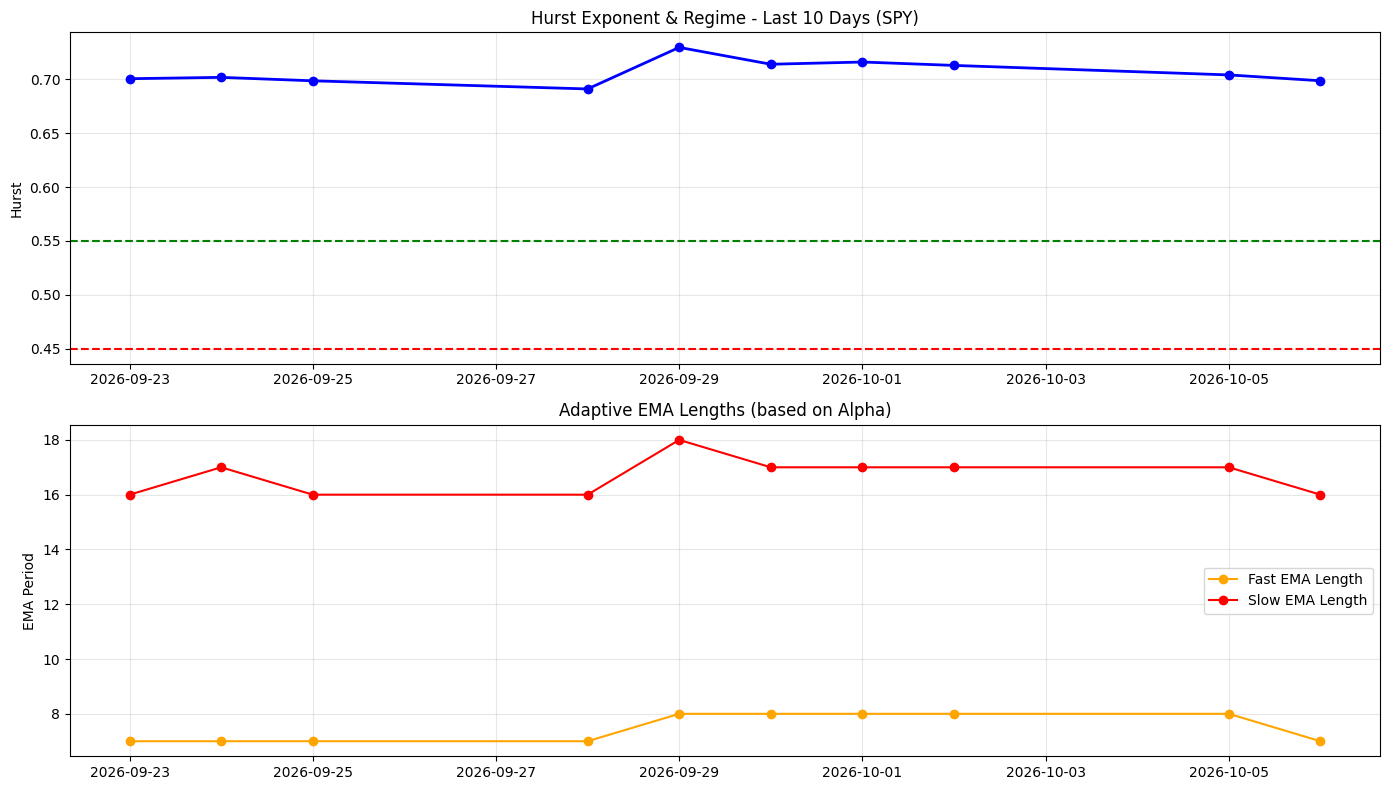

In [22]:

def get_prices(ticker="SPY", period="2y"):
    df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
    return df["Close"].dropna()

def hurst_exponent(ts):
    ts = np.asarray(ts, dtype=float)
    if len(ts) < 100:
        return np.nan
    try:
        H, _, _ = compute_Hc(ts, kind="price", simplified=True)
        return H
    except:
        return np.nan

def get_regime(h):
    if np.isnan(h):
        return "Unknown"
    elif h > 0.55:
        return "Trending — Momentum Favoured"
    elif h < 0.45:
        return "Mean Reverting — Counter-trend Favoured"
    else:
        return "Random Walk — Reduce Size"

# ====================== NEW FUNCTIONS ======================
def ema_length(alpha, n_min, n_max, k=2):
    """Convert market memory alpha into EMA length"""
    return n_min + (n_max - n_min) * (1 - alpha) ** k

def adaptive_ema_lengths(alpha):
    """Returns fast and slow EMA lengths"""
    fast = ema_length(alpha, n_min=5, n_max=20, k=2)
    slow = ema_length(alpha, n_min=10, n_max=50, k=2)
    return int(round(fast)), int(round(slow))

# ====================== ROLLING HURST ======================
def rolling_hurst(prices, window=180):
    hurst_vals = []
    dates = []
    valid = 0

    print("Calculating rolling Hurst...")

    for i in range(window, len(prices)):
        chunk = prices.iloc[i-window:i].values
        h = hurst_exponent(chunk)
        hurst_vals.append(h)
        dates.append(prices.index[i])

        if not np.isnan(h):
            valid += 1

        if i % 100 == 0:
            print(f"Progress: {i}/{len(prices)} | Valid: {valid}", end="\r")

    H = pd.Series(hurst_vals, index=dates, name="Hurst")
    print(f"\nFinished! Valid Hurst values: {valid}/{len(H)}")
    return H


def calculate_hurst_for_indices(tickers, window=180, period="5y"):
    """
    Calculate rolling Hurst exponent for multiple indices/sectors.
    """

    hurst_data = {}

    for name, ticker in tickers.items():

        print(f"\n{'='*70}")
        print(f"Processing: {name} ({ticker})")
        print(f"{'='*70}")

        try:
            prices = get_prices(ticker, period=period)

            if len(prices) < window + 100:
                print(f"Not enough data for {name}")
                continue

            H = rolling_hurst(prices, window=window)

            hurst_data[name] = H

        except Exception as e:
            print(f"Error processing {name}: {e}")

    return pd.DataFrame(hurst_data)

INDEX_TICKERS = {

    "S&P 500": "SPY",

    # Replace these with the Yahoo Finance tickers
    # for the sector indices you want to monitor

    "Financials": "XLF",
    "Materials": "XLB",
    "Energy": "XLE",
    "Industrials": "XLI",
    "Healthcare": "XLV",
    "Consumer Staples": "XLP",
    "Consumer Discretionary": "XLY",
    "Information Technology": "XLK",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
    "Communication Services": "XLC"
}
# ====================== RUN ======================

ticker = "SPY"
prices = get_prices(ticker)

H = rolling_hurst(prices, window=180)
alpha = np.clip(2 - 2 * H, 0, 1)
k_alpha = 0.5 + 1.5*(1-alpha)

# Create main dataframe
df = pd.DataFrame({
    "Hurst": H,
    "Alpha": alpha,
    "K_Alpha": k_alpha,
    "Regime": H.apply(get_regime)
})

# Add Adaptive EMA Lengths
df['Fast_EMA_Len'], df['Slow_EMA_Len'] = zip(*df['Alpha'].apply(adaptive_ema_lengths))

# Calculate actual EMAs using adaptive lengths (using latest Alpha for simplicity)
latest_alpha = df['Alpha'].iloc[-1]
#latest_Kalpha = df['K_Alpha'].iloc[-1]
#fast_len, slow_len = adaptive_ema_lengths(latest_alpha)

latest_Kalpha = 1
fast_len, slow_len = 8, 15

df['Fast_EMA'] = prices.ewm(span=fast_len, adjust=False).mean()
df['Slow_EMA'] = prices.ewm(span=slow_len, adjust=False).mean()

# Last 10 days
last10 = df.dropna().tail(10)

print("\n" + "="*100)
print("Last 10 Days - Hurst, Alpha, K_Alpha, Regime & Adaptive EMAs")
print(last10[['Hurst', 'Alpha','K_Alpha', 'Regime', 'Fast_EMA_Len', 'Slow_EMA_Len']].round(4))

print(f"\nCurrent Adaptive EMAs (based on latest Alpha):")
print(f"Fast EMA Length : {fast_len}")
print(f"Slow EMA Length : {slow_len}")
print(f"Current Market Memory : {latest_alpha}")
print(f"Current k Alpha : {latest_Kalpha}")

# Plot
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(last10.index, last10["Hurst"], marker='o', color='blue', linewidth=2)
plt.axhline(0.55, color='green', linestyle='--')
plt.axhline(0.45, color='red', linestyle='--')
plt.title(f"Hurst Exponent & Regime - Last 10 Days ({ticker})")
plt.ylabel("Hurst")
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(last10.index, last10["Fast_EMA_Len"], marker='o', label='Fast EMA Length', color='orange')
plt.plot(last10.index, last10["Slow_EMA_Len"], marker='o', label='Slow EMA Length', color='red')
plt.title("Adaptive EMA Lengths (based on Alpha)")
plt.ylabel("EMA Period")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
#Calculate all rolling Hurst series
H_all = calculate_hurst_for_indices(
    INDEX_TICKERS,
    window=180,
    period="5y"
)

print("\nHurst Data:")
H_all.tail()




Processing: S&P 500 (SPY)
Calculating rolling Hurst...

Finished! Valid Hurst values: 1074/1074

Processing: Financials (XLF)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1074/1074

Processing: Materials (XLB)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1074/1074

Processing: Energy (XLE)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1074/1074

Processing: Industrials (XLI)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1074/1074

Processing: Healthcare (XLV)
Calculating rolling Hurst...

Finished! Valid Hurst values: 1074/1074

Processing: Consumer Staples (XLP)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1074/1074

Processing: Consumer Discretionary (XLY)
Calculating rolling Hurst...
Progress: 1200/1254 | Valid: 1021
Finished! Valid Hurst values: 1

,S&P 500,Financials,Materials,Energy,Industrials,Healthcare,Consumer Staples,Consumer Discretionary,Information Technology,Real Estate,Utilities,Communication Services
2026-09-30,0.714068,0.646557,0.414858,0.674475,0.499310,0.595056,0.423151,0.493758,0.733877,0.497238,0.506872,0.421225
2026-10-01,0.716146,0.612776,0.414819,0.666930,0.502689,0.603250,0.382116,0.468487,0.749098,0.489622,0.493568,0.408134
2026-10-02,0.712985,0.610169,0.418437,0.639807,0.507700,0.588664,0.375795,0.437716,0.737036,0.476497,0.495019,0.386792
2026-10-05,0.704161,0.630224,0.417058,0.632461,0.504703,0.606493,0.397304,0.441749,0.721597,0.492235,0.493099,0.376248
2026-10-06,0.698743,0.663497,0.424974,0.621763,0.519324,0.618054,0.398479,0.439627,0.722520,0.494907,0.495463,0.397649


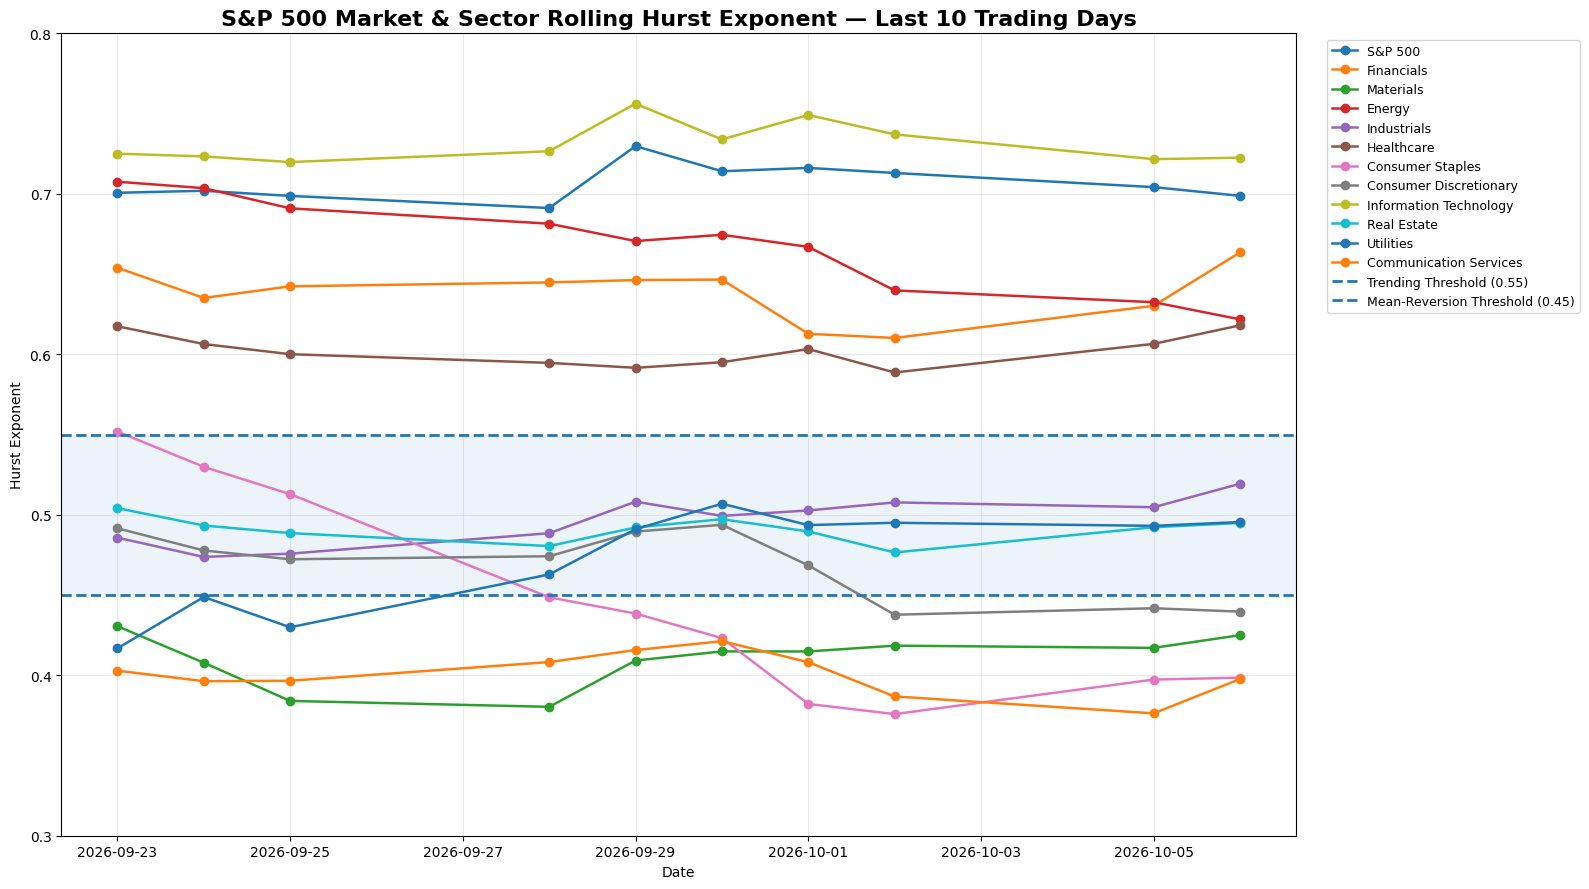

In [24]:
# ==============================
# LAST 10 TRADING DAYS
# ==============================

H_last10 = H_all.tail(10)

plt.figure(figsize=(16, 9))

for column in H_last10.columns:
    plt.plot(
        H_last10.index,
        H_last10[column],
        marker='o',
        linewidth=1.8,
        label=column
    )

# Regime boundaries
plt.axhline(
    0.55,
    linestyle="--",
    linewidth=2,
    label="Trending Threshold (0.55)"
)

plt.axhline(
    0.45,
    linestyle="--",
    linewidth=2,
    label="Mean-Reversion Threshold (0.45)"
)

# Neutral zone
plt.axhspan(
    0.45,
    0.55,
    alpha=0.08
)

plt.title(
    "S&P 500 Market & Sector Rolling Hurst Exponent — Last 10 Trading Days",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Hurst Exponent")
plt.xlabel("Date")

plt.ylim(0.30, 0.80)

plt.grid(True, alpha=0.25)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9
)

plt.tight_layout()
plt.show()

In [25]:
latest = H_all.ffill().iloc[-1].sort_values(ascending=False)

regime_summary = pd.DataFrame({
    "Hurst": latest,
    "Regime": latest.apply(get_regime)
})

regime_summary["Distance from 0.55"] = (
    regime_summary["Hurst"] - 0.55
)

regime_summary = regime_summary.round(4)

print("\nCURRENT HURST REGIME")
print("=" * 80)
regime_summary


CURRENT HURST REGIME


,Hurst,Regime,Distance from 0.55
Information Technology,0.7225,Trending — Momentum Favoured,0.1725
S&P 500,0.6987,Trending — Momentum Favoured,0.1487
Financials,0.6635,Trending — Momentum Favoured,0.1135
Energy,0.6218,Trending — Momentum Favoured,0.0718
Healthcare,0.6181,Trending — Momentum Favoured,0.0681
Industrials,0.5193,Random Walk — Reduce Size,-0.0307
Utilities,0.4955,Random Walk — Reduce Size,-0.0545
Real Estate,0.4949,Random Walk — Reduce Size,-0.0551
Consumer Discretionary,0.4396,Mean Reverting — Counter-trend Favoured,-0.1104
Materials,0.4250,Mean Reverting — Counter-trend Favoured,-0.1250


In [26]:
def regime_persistence(H, threshold=0.55, lookback=30):

    recent = H.tail(lookback)

    trending_pct = (recent > threshold).mean() * 100
    mean_reverting_pct = (recent < 0.45).mean() * 100
    random_walk_pct = (
        ((recent >= 0.45) & (recent <= 0.55)).mean() * 100
    )

    return pd.Series({
        "Current Hurst": recent.iloc[-1],
        "Trending %": trending_pct,
        "Random Walk %": random_walk_pct,
        "Mean Reverting %": mean_reverting_pct
    })

# percentage of the last N observations that the sector has been trending.
persistence = pd.DataFrame({
    sector: regime_persistence(H_all[sector], lookback=30)
    for sector in H_all.columns
}).T

persistence.round(2)

,Current Hurst,Trending %,Random Walk %,Mean Reverting %
S&P 500,0.70,100.00,0.00,0.00
Financials,0.66,100.00,0.00,0.00
Materials,0.42,13.33,53.33,33.33
Energy,0.62,100.00,0.00,0.00
Industrials,0.52,33.33,66.67,0.00
Healthcare,0.62,100.00,0.00,0.00
Consumer Staples,0.40,50.00,26.67,23.33
Consumer Discretionary,0.44,0.00,90.00,10.00
Information Technology,0.72,100.00,0.00,0.00
Real Estate,0.49,13.33,86.67,0.00


In [27]:
today = datetime.today()
five_days_ago = today - timedelta(days=5)
start_of_year = today.replace(month=1, day=1)

# First day of this month
first_day_month = today.replace(day=1)

# First day of this week (Monday as weekday 0)
first_day_week = today - timedelta(days=today.weekday())
print("First day of year:", start_of_year)

print("\nFirst day of this month:", first_day_month)
print("\nFirst day of this week:", first_day_week)

def most_recent_quarter_start(today=None):
    if today is None:
        today = pd.Timestamp.today().normalize()
    year = today.year
    month = today.month

    # Determine quarter start months: Jan, Apr, Jul, Oct
    if month >= 10:
        q_start = pd.Timestamp(year, 10, 1)
    elif month >= 7:
        q_start = pd.Timestamp(year, 7, 1)
    elif month >= 4:
        q_start = pd.Timestamp(year, 4, 1)
    else:
        q_start = pd.Timestamp(year, 1, 1)

    return q_start

# Example usage
print("Today:", pd.Timestamp.today().normalize())
print("Most recent quarter start:", most_recent_quarter_start())
print("Five days ago:", five_days_ago)

First day of year: 2026-01-01 03:41:40.129734

First day of this month: 2026-10-01 03:41:40.129734

First day of this week: 2026-10-05 03:41:40.129734
Today: 2026-10-07 00:00:00
Most recent quarter start: 2026-10-01 00:00:00
Five days ago: 2026-10-02 03:41:40.129734


In [28]:
def get_last_quad_witching(reference_date=None):
    """
    Returns the most recent quad witching date (3rd Friday of Mar/Jun/Sep/Dec)
    before or equal to reference_date.
    """
    import calendar
    from datetime import date, timedelta

    if reference_date is None:
        reference_date = date.today()
    elif isinstance(reference_date, str):
        reference_date = pd.to_datetime(reference_date).date()

    quad_months = [3, 6, 9, 12]

    def third_friday(year, month):
        # Find first day of month
        first_day = date(year, month, 1)
        # Find first Friday
        first_friday = first_day + timedelta(days=(4 - first_day.weekday()) % 7)
        # Third Friday = first Friday + 14 days
        return first_friday + timedelta(days=14)

    # Generate last 2 years of quad witching dates
    candidates = []
    for year in [reference_date.year - 1, reference_date.year]:
        for month in quad_months:
            candidates.append(third_friday(year, month))

    # Filter to dates on or before reference_date
    past_dates = [d for d in candidates if d <= reference_date]

    # Return most recent
    return max(past_dates).strftime("%Y-%m-%d")

In [29]:
# List of ETFs to analyze
df_raw = pd.read_csv('sp500_list.csv')
df_raw =df_raw.drop_duplicates(subset=['Asset'])
df_raw = df_raw[df_raw['Type'].isin(['Stock'])]
recent_quarter = most_recent_quarter_start()
etfs = df_raw['Asset'].to_list()
print(etfs)

print(len(etfs))

['MRNA', 'P', 'HPE', 'PTC', 'LITE', 'MPC', 'CRWD', 'SMCI', 'VLO', 'ILMN', 'NTAP', 'PSX', 'PLTR', 'AMD', 'RVTY', 'VEEV', 'ZBRA', 'DELL', 'SWKS', 'ACN', 'PANW', 'META', 'MSFT', 'SNPS', 'A', 'FTNT', 'KEYS', 'DDOG', 'APA', 'HPQ', 'CRL', 'IT', 'ANET', 'TER', 'TMO', 'FFIV', 'MTD', 'MPWR', 'WBD', 'NVDA', 'NOW', 'ADI', 'XOM', 'IQV', 'CVX', 'CEG', 'CRM', 'PWR', 'WAT', 'COP', 'COHR', 'JCI', 'EMR', 'MCK', 'DVN', 'NDSN', 'FCX', 'TRMB', 'ULTA', 'EXPD', 'BE', 'UHS', 'ETN', 'DHR', 'TEL', 'WSM', 'WAB', 'EME', 'WST', 'AME', 'VRSN', 'APH', 'PFE', 'CPAY', 'GDDY', 'AAPL', 'IEX', 'COIN', 'HCA', 'INTC', 'MU', 'ABBV', 'VTRS', 'BIIB', 'FAST', 'PM', 'MET', 'GILD', 'DE']
89


## Filter for liquidity

In [30]:

# Filter ETFs or stocks for liquidity
def filter_by_liquidity(etf_df, ticker_col="Asset", min_dollar_vol=10e6, lookback_days=30):
    liquid_etfs = []

    for ticker in etf_df[ticker_col]:
        try:
            # Fetch daily historical data
            data = yf.download(ticker, period=f"{lookback_days*2}d", interval="1d", auto_adjust=True)

            if data.empty:
                continue

            # Calculate dollar volume (Close × Volume)
            data["dollar_volume"] = data["Close"] * data["Volume"]

            # Calculate rolling average over lookback_days
            avg_dollar_volume = data["dollar_volume"].rolling(window=lookback_days).mean().iloc[-1]

            # Check liquidity condition
            if avg_dollar_volume >= min_dollar_vol:
                liquid_etfs.append(ticker)

        except Exception as e:
            print(f"Error fetching {ticker}: {e}")

    # Return filtered DataFrame
    return etf_df[etf_df[ticker_col].isin(liquid_etfs)]

# Example usage
df = pd.DataFrame({"Assets": etfs})
liquid_df = filter_by_liquidity(df, ticker_col="Assets")
df_o = df_raw[df_raw['Asset'].isin(liquid_df['Assets'])]
etfs2 = df_o['Asset'].to_list()
etfs = list(dict.fromkeys(etfs2))
print("")
print(etfs)
print(len(etfs))



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


['MRNA', 'P', 'HPE', 'PTC', 'LITE', 'MPC', 'CRWD', 'SMCI', 'VLO', 'ILMN', 'NTAP', 'PSX', 'PLTR', 'AMD', 'RVTY', 'VEEV', 'ZBRA', 'DELL', 'SWKS', 'ACN', 'PANW', 'META', 'MSFT', 'SNPS', 'A', 'FTNT', 'KEYS', 'DDOG', 'APA', 'HPQ', 'CRL', 'IT', 'ANET', 'TER', 'TMO', 'FFIV', 'MTD', 'MPWR', 'WBD', 'NVDA', 'NOW', 'ADI', 'XOM', 'IQV', 'CVX', 'CEG', 'CRM', 'PWR', 'WAT', 'COP', 'COHR', 'JCI', 'EMR', 'MCK', 'DVN', 'NDSN', 'FCX', 'TRMB', 'ULTA', 'EXPD', 'BE', 'UHS', 'ETN', 'DHR', 'TEL', 'WSM', 'WAB', 'EME', 'WST', 'AME', 'VRSN', 'APH', 'PFE', 'CPAY', 'GDDY', 'AAPL', 'IEX', 'COIN', 'HCA', 'INTC', 'MU', 'ABBV', 'VTRS', 'BIIB', 'FAST', 'PM', 'MET', 'GILD', 'DE']
89


# Classify Sector Stages

In [31]:

def kaufman_er_pine(ticker, period=10, lookback="3mo"):
    data = yf.download(
        ticker,
        period=lookback,
        interval="1d",
        auto_adjust=False,   # match Pine
        progress=False
    )

    if data.empty:
        return np.nan

    close = data["Close"].squeeze()

    # Directional movement (matches Pine)
    direction = close.iloc[-1] - close.iloc[-period]

    # Total absolute movement (matches Pine)
    volatility = close.diff().abs().iloc[-period:].sum()

    if volatility == 0:
        return 0.0

    return (direction / volatility) * 100   # Pine scaling


def weinstein_stage(df, sma_window=30,smaSlope_window=5):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()
    df["10_SMA"] = df["Close"].rolling(window=10).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(smaSlope_window), df["SMA"].tail(smaSlope_window))
    #slope_short, _, _, _, _ = linregress(range(smaSlope_window), df["10_SMA"].tail(smaSlope_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma   = df["SMA"].iloc[-1]
    latest_10sma = df["10_SMA"].iloc[-1]

    # Determine stage
    if (latest_price > latest_sma) and (slope > 0) : #and (latest_price > latest_10sma) and (latest_10sma > latest_sma):
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif np.abs(slope) <= 0.001:
        stage = "Stage 1 (Basing)"
    else:
        stage = "Stage 3 (Topping)"

    return stage, slope, latest_price, latest_sma, latest_10sma


In [32]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma,sma_10 = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma,
            "10W_SMA": sma_10
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)

advancing_stocks= stages_df[stages_df["Stage"] .isin(["Stage 2 (Advancing)"]) ]
advancing_stocks.reset_index(drop=True, inplace=True)

# List of ETFs to analyze
df_1 = df_o[df_o['Asset'].isin(advancing_stocks['ETF'])]
etfs2 = df_1['Asset'].to_list()
etfs_cleanss = list(dict.fromkeys(etfs2))

er_values = {
    ticker: kaufman_er_pine(ticker)
    for ticker in etfs_cleanss
}

etfs_cleans= [
    ticker
    for ticker, er in er_values.items()
    if er > 0.0
]

print(len(etfs_cleans))


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

57


## Multi-timeframe Analysis for stop loss placement

In [33]:

# ---------------------------------------------------------
# 1. Pine Script pivot-order mapping
# ---------------------------------------------------------
def pivot_order_from_timeframe(tf: str) -> int:
    tf = tf.lower()

    # Minutes
    if tf.endswith("m"):
        minutes = int(tf.replace("m", ""))
        if minutes == 30:
            return 7
        else:
            return 10

    # Daily
    if tf in ("1d", "d"):
        return 5

    # Weekly
    if tf in ("1w", "w"):
        return 5

    # Monthly
    if tf in ("1m", "m"):
        return 3

    # Default
    return 10


# ---------------------------------------------------------
# 2. Full market structure detection
# ---------------------------------------------------------
def new_market_structure(df: pd.DataFrame, timeframe: str):
    """
    Returns ALL HH, HL, LH, LL swing points.
    Also returns most recent HL (long SL) and LH (short SL).
    """

    # Normalize column names
    df = df.rename(columns=str.lower)

    required = {"high", "low"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    pivot_order = pivot_order_from_timeframe(timeframe)

    high = df["high"].to_numpy()
    low  = df["low"].to_numpy()

    # -----------------------------------------------------
    # 2a. Confirmed swing highs/lows
    # -----------------------------------------------------
    swing_high_idx = argrelextrema(high, np.greater_equal, order=pivot_order)[0]
    swing_low_idx  = argrelextrema(low,  np.less_equal,    order=pivot_order)[0]

    swings = []
    prev_high = None
    prev_low = None

    # -----------------------------------------------------
    # 2b. Classify swing highs (HH / LH)
    # -----------------------------------------------------
    for idx in swing_high_idx:
        price = high[idx]
        label = "HH" if (prev_high is None or price >= prev_high) else "LH"
        swings.append({"idx": idx, "price": price, "type": label})
        prev_high = price

    # -----------------------------------------------------
    # 2c. Classify swing lows (HL / LL)
    # -----------------------------------------------------
    for idx in swing_low_idx:
        price = low[idx]
        label = "HL" if (prev_low is None or price >= prev_low) else "LL"
        swings.append({"idx": idx, "price": price, "type": label})
        prev_low = price

    # -----------------------------------------------------
    # 2d. Sort swings by time
    # -----------------------------------------------------
    swings = sorted(swings, key=lambda x: x["idx"])

    # -----------------------------------------------------
    # 2e. Extract most recent HL and LH
    # -----------------------------------------------------
    recent_HL = next((s for s in reversed(swings) if s["type"] == "HL"), None)
    recent_LH = next((s for s in reversed(swings) if s["type"] == "LH"), None)
    recent_HH = next((s for s in reversed(swings) if s["type"] == "HH"), None)
    recent_LL = next((s for s in reversed(swings) if s["type"] == "LL"), None)

    return {
        "pivot_order": pivot_order,
        "swings": swings,       # ALL HH, HL, LH, LL
        "recent_HL": recent_HL, # SL for long trades
        "recent_LH": recent_LH ,  # SL for short trades
        "recent_HH": recent_HH,
        "recent_LL": recent_LL
    }



def new_structure_alignment(inner, outer):
    """
    Multi-timeframe structure alignment for LONG/SHORT.
    Returns a DataFrame with:
        long_ok
        short_ok
        reason
        stop_loss_long
        stop_loss_short
    """

    inner_HL = inner["recent_HL"]
    inner_LH = inner["recent_LH"]
    outer_HL = outer["recent_HL"]
    outer_LH = outer["recent_LH"]

    long_ok = False
    short_ok = False
    reason = ""
    stop_loss_long = None
    stop_loss_short = None

    # ---------------------------------------------------------
    # LONG ALIGNMENT (HL ≥ HL)
    # ---------------------------------------------------------
    if inner_HL and outer_HL:
        if inner_HL["price"] >= outer_HL["price"]:
            long_ok = True
            stop_loss_long = inner_HL["price"]
        else:
            reason = (
                f"Inner HL ({inner_HL['price']}) is BELOW outer HL "
                f"({outer_HL['price']}) → inner trend weaker → skip longs."
            )

    # ---------------------------------------------------------
    # SHORT ALIGNMENT (LH ≤ LH)
    # ---------------------------------------------------------
    if inner_LH and outer_LH:
        if inner_LH["price"] <= outer_LH["price"]:
            short_ok = True
            stop_loss_short = inner_LH["price"]
        else:
            reason = (
                f"Inner LH ({inner_LH['price']}) is ABOVE outer LH "
                f"({outer_LH['price']}) → inner trend weaker → skip shorts."
            )

    # ---------------------------------------------------------
    # Positive reasons if aligned
    # ---------------------------------------------------------
    if long_ok and not reason:
        reason = "Inner + outer structure aligned for LONG."

    if short_ok and not reason:
        reason = "Inner + outer structure aligned for SHORT."

    # ---------------------------------------------------------
    # Return as DataFrame
    # ---------------------------------------------------------
    df = pd.DataFrame([{
        "long_ok": long_ok,
        "short_ok": short_ok,
        "reason": reason,
        "stop_loss_long": stop_loss_long,
        "stop_loss_short": stop_loss_short
    }])

    return df



## Mansfield Realtive Strength

In [34]:

def mansfield_rs(tickers, index_ticker, lookback=52):
    """
    Replicate the original StageAnalysis Mansfield RS calculation.

    Uses WEEKLY data, matching the Pine Script:

        resolution = '1W'
        maLength = 52

    Mansfield RS:
        ((RS Ratio / 52-week SMA of RS Ratio) - 1) * 100

    Also determines the direction of the Mansfield RS line itself.
    """

    # =========================================================
    # DOWNLOAD BENCHMARK
    # =========================================================

    idx_data = yf.download(
        index_ticker,
        period="5y",
        interval="1wk",
        auto_adjust=True,
        progress=False
    )

    if idx_data.empty:
        raise ValueError(
            f"No data returned for {index_ticker}"
        )

    if isinstance(idx_data.columns, pd.MultiIndex):
        idx = idx_data["Close"].squeeze()
    else:
        idx = idx_data["Close"]

    idx = pd.to_numeric(
        idx,
        errors="coerce"
    ).dropna()

    idx.name = "index"

    results = []

    # =========================================================
    # PROCESS EACH STOCK
    # =========================================================

    for ticker in tickers:

        try:

            data = yf.download(
                ticker,
                period="5y",
                interval="1wk",
                auto_adjust=True,
                progress=False
            )

            if data.empty:
                print(
                    f"⚠ No data for {ticker}. Skipping."
                )
                continue

            if isinstance(data.columns, pd.MultiIndex):
                stock = data["Close"].squeeze()
            else:
                stock = data["Close"]

            stock = pd.to_numeric(
                stock,
                errors="coerce"
            ).dropna()

            stock.name = "stock"

            # =================================================
            # ALIGN STOCK AND INDEX
            # =================================================

            df = pd.concat(
                [stock, idx],
                axis=1,
                join="inner"
            ).dropna()

            if len(df) < lookback + 10:
                print(
                    f"⚠ Not enough data for {ticker}. "
                    f"Only {len(df)} weekly observations."
                )
                continue

            # =================================================
            # RS RATIO
            # =================================================

            df["rs_ratio"] = (
                df["stock"] /
                df["index"]
            ) * 100

            # =================================================
            # 52-WEEK MA OF RS RATIO
            # =================================================

            df["rs_ma"] = (
                df["rs_ratio"]
                .rolling(
                    window=lookback,
                    min_periods=lookback
                )
                .mean()
            )

            # =================================================
            # MANSFIELD RS
            # =================================================

            df["mansfield_rs"] = (
                (
                    df["rs_ratio"] /
                    df["rs_ma"]
                ) - 1
            ) * 100

            # =================================================
            # REMOVE NaN VALUES
            # =================================================

            valid = df["mansfield_rs"].dropna()

            if len(valid) < 2:
                print(
                    f"⚠ Insufficient Mansfield RS "
                    f"data for {ticker}."
                )
                continue

            # =================================================
            # DIRECTION OF THE MANSFIELD RS LINE
            # =================================================

            current_rs = valid.iloc[-1]
            previous_rs = valid.iloc[-2]

            if current_rs > previous_rs:
                rs_direction = "Rising"

            elif current_rs < previous_rs:
                rs_direction = "Falling"

            else:
                rs_direction = "Flat"

            # =================================================
            # 5-WEEK DIRECTION
            # =================================================

            if len(valid) >= 6:

                rs_5w_change = (
                    current_rs -
                    valid.iloc[-6]
                )

                if rs_5w_change > 0:
                    rs_5w_direction = "Rising"

                elif rs_5w_change < 0:
                    rs_5w_direction = "Falling"

                else:
                    rs_5w_direction = "Flat"

            else:

                rs_5w_change = np.nan
                rs_5w_direction = "N/A"

            # =================================================
            # STORE RESULT
            # =================================================

            latest_date = valid.index[-1]

            results.append({

                "ticker": ticker,

                "date": latest_date,

                "last_price":
                    df.loc[
                        latest_date,
                        "stock"
                    ],

                "rs_ratio":
                    df.loc[
                        latest_date,
                        "rs_ratio"
                    ],

                "rs_ma_52w":
                    df.loc[
                        latest_date,
                        "rs_ma"
                    ],

                "mansfield_rs":
                    current_rs,

                "rs_1w_change":
                    current_rs - previous_rs,

                "rs_direction":
                    rs_direction,

                "rs_5w_change":
                    rs_5w_change,

                "rs_5w_direction":
                    rs_5w_direction
            })

        except Exception as e:

            print(
                f"❌ Error processing "
                f"{ticker}: {e}"
            )

    # =========================================================
    # RESULTS
    # =========================================================

    results_df = pd.DataFrame(results)

    if results_df.empty:
        return results_df

    return (
        results_df
        .sort_values(
            "mansfield_rs",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [35]:
# Calculaet Mansfield
results = mansfield_rs(
    tickers=etfs_cleans,
    index_ticker="SPY",
    lookback=52
)

#results_1 =results[(results['mansfield_rs']>0) ]
results_1 =results[(results['mansfield_rs']>0) | (results['rs_direction'].isin(['Rising']) ) ]
results_1.reset_index(drop=True, inplace=True)


etfs_clean = results_1['ticker'].to_list()
print(len(etfs_clean))



55


# Brian Shannon daily timeframe stage classification

In [36]:

@dataclass
class ClassifierConfig:
    short_ma:       int   = 20
    medium_ma:      int   = 50
    long_ma:        int   = 200
    atr_period:     int   = 14
    slope_period:   int   = 10       # wider slope window = less noise
    rs_period:      int   = 63       # 3-month RS — more meaningful
    volume_period:  int   = 50       # 50-bar vol average — institutional grade
    pivot_lookback: int   = 10       # wider pivot = fewer false swings

    # ── Strictness preset
    # "strict"   — original settings, high conviction only
    # "balanced" — recommended, catches more valid setups
    # "relaxed"  — widest net, use with additional filters downstream
    strictness: str = "balanced"

    def __post_init__(self):
        """Auto-configure thresholds based on strictness level."""

        presets = {

            "strict": {
                # Stage 2
                "stage2_min_score":       7,
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": 0.0,    # all three MAs must rise
                # Stage 1
                "stage1_slope_max":       0.03,
                "stage1_atr_max":         0.04,
                "stage1_ma50_proximity":  0.07,
                # Stage 4
                "stage4_rs_penalty":     -0.05,   # must underperform by 5%
            },

            "balanced": {
                # Stage 2
                "stage2_min_score":       6,       # down from 7
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": -0.01,   # 200 MA can be very slightly negative
                                                    # catches early Stage 2 before 200 MA turns
                # Stage 1
                "stage1_slope_max":       0.04,    # slightly looser
                "stage1_atr_max":         0.05,
                "stage1_ma50_proximity":  0.08,
                # Stage 4
                "stage4_rs_penalty":     -0.02,    # less strict RS requirement
            },

            "relaxed": {
                # Stage 2
                "stage2_min_score":       5,       # catches more early setups
                "stage2_ma50_slope_min":  0.0,
                "stage2_ma200_slope_min": -0.03,   # 200 MA can still be declining
                                                    # valid for early Stage 2 breakouts
                # Stage 1
                "stage1_slope_max":       0.06,
                "stage1_atr_max":         0.06,
                "stage1_ma50_proximity":  0.10,
                # Stage 4
                "stage4_rs_penalty":      0.0,     # any negative RS qualifies
            },
        }

        if self.strictness not in presets:
            raise ValueError(
                f"strictness must be 'strict', 'balanced' or 'relaxed' "
                f"— got '{self.strictness}'"
            )

        preset = presets[self.strictness]

        # Stage 2
        self.stage2_min_score       = preset["stage2_min_score"]
        self.stage2_ma50_slope_min  = preset["stage2_ma50_slope_min"]
        self.stage2_ma200_slope_min = preset["stage2_ma200_slope_min"]

        # Stage 1
        self.stage1_slope_max       = preset["stage1_slope_max"]
        self.stage1_atr_max         = preset["stage1_atr_max"]
        self.stage1_ma50_proximity  = preset["stage1_ma50_proximity"]

        # Stage 4
        self.stage4_rs_penalty      = preset["stage4_rs_penalty"]



# =============================================================
# CLASSIFIER
# =============================================================

class BrianShannonAuctionClassifier:
    """
    Improved Brian Shannon Auction Market Stage Classifier.

    Improvements over original:
    ----------------------------
    1.  Wider slope window (10 bars) — reduces slope noise
    2.  3-month RS period — more institutionally meaningful
    3.  MA200 slope condition added to Stage 2 — prevents false markups
    4.  Stage 1 uses tighter slope + ATR thresholds
    5.  Stage 4 requires negative RS — removes weak/sideways false declines
    6.  Weighted trend score — not all signals are equal
    7.  Stage confidence score added — tells you how strong each call is
    8.  Stage transition detection — flags when stage is changing
    9.  RS percentile rank — tells you where RS stands vs its own history
    10. Multi-stock scanner built in — scan a list and get ranked results
    """

    def __init__(self, config: Optional[ClassifierConfig] = None):
        self.config = config or ClassifierConfig()

    # =========================================================
    # PUBLIC — SINGLE STOCK
    # =========================================================
    def classify(self, df: pd.DataFrame) -> pd.DataFrame:

        df = df.copy()

        self._moving_averages(df)
        self._atr(df)
        self._relative_strength(df)
        self._volume_analysis(df)
        self._trend_structure(df)
        self._trend_score(df)
        self._classify_stages(df)
        self._stage_confidence(df)
        self._stage_transitions(df)

        return df

    # =========================================================
    # PUBLIC — MULTI STOCK SCANNER
    # =========================================================
    def scan(
        self,
        tickers:    list,
        benchmark:  str  = "SPY",
        start:      str  = "2022-01-01",
        min_score:  int  = 0,
        stage_filter: Optional[int] = None
    ) -> pd.DataFrame:
        """
        Scan a list of tickers and return a ranked summary DataFrame.

        Parameters
        ----------
        tickers      : list of ticker symbols
        benchmark    : benchmark ticker for RS (default SPY)
        start        : start date for data download
        min_score    : minimum trend_score to include in results
        stage_filter : filter by stage number (1/2/3/4) or None for all

        Returns
        -------
        pd.DataFrame sorted by trend_score descending
        """

        print(f"\nDownloading benchmark ({benchmark})...")
        spy_data = yf.download(benchmark, start=start, progress=False)

        results = []

        for i, ticker in enumerate(tickers, 1):

            print(f"[{i}/{len(tickers)}] Processing {ticker}...", end=" ")

            try:

                data = yf.download(ticker, start=start, progress=False)

                if data.empty or len(data) < self.config.long_ma + 10:
                    print("SKIP — insufficient data")
                    continue

                # flatten multi-level columns if present
                if isinstance(data.columns, pd.MultiIndex):
                    data.columns = data.columns.get_level_values(0)

                data["benchmark_close"] = spy_data["Close"].reindex(
                    data.index
                ).ffill()

                classified = self.classify(data)
                latest     = classified.iloc[-1]
                prev       = classified.iloc[-2]

                results.append({
                    "Ticker":        ticker,
                    "Close":         round(latest["Close"], 2),
                    "Stage":         int(latest["stage_number"])
                                     if not np.isnan(latest["stage_number"])
                                     else 0,
                    "Stage Label":   latest["stage"],
                    "Trend Score":   int(latest["trend_score"]),
                    "Confidence":    round(latest["stage_confidence"], 1),
                    "RS (3M)":       round(latest["rs"] * 100, 2)
                                     if not np.isnan(latest["rs"]) else np.nan,
                    "RS Percentile": round(latest["rs_percentile"], 1)
                                     if not np.isnan(latest["rs_percentile"])
                                     else np.nan,
                    "Transitioning": latest["stage_transitioning"],
                    "MA20":          round(latest["ma20"], 2),
                    "MA50":          round(latest["ma50"], 2),
                    "MA200":         round(latest["ma200"], 2),
                    "ATR%":          round(latest["atr_pct"] * 100, 2),
                    "Vol Ratio":     round(latest["volume_ratio"], 2),
                    "Accum Days":    int(
                                         classified["accumulation_day"]
                                         .tail(10).sum()
                                     ),
                    "Dist Days":     int(
                                         classified["distribution_day"]
                                         .tail(10).sum()
                                     ),
                })

                print(f"{latest['stage']} | Score: {int(latest['trend_score'])} | Conf: {round(latest['stage_confidence'], 1)}%")

            except Exception as e:
                print(f"ERROR — {e}")
                continue

        if not results:
            print("No results returned.")
            return pd.DataFrame()

        df_results = pd.DataFrame(results)

        # apply filters
        if min_score > 0:
            df_results = df_results[df_results["Trend Score"] >= min_score]

        if stage_filter is not None:
            df_results = df_results[df_results["Stage"] == stage_filter]

        # sort by trend score then confidence
        df_results = df_results.sort_values(
            ["Trend Score", "Confidence"],
            ascending=False
        ).reset_index(drop=True)

        return df_results

    # =========================================================
    # LATEST STAGE — SINGLE STOCK
    # =========================================================
    def latest_stage(self, df: pd.DataFrame) -> dict:

        latest = df.iloc[-1]

        return {
            "date":          latest.name,
            "close":         round(latest["Close"], 2),
            "stage":         latest["stage"],
            "stage_number":  latest["stage_number"],
            "trend_score":   int(latest["trend_score"]),
            "confidence":    round(latest["stage_confidence"], 1),
            "rs_3m":         round(latest["rs"] * 100, 2)
                             if not np.isnan(latest["rs"]) else None,
            "rs_percentile": round(latest["rs_percentile"], 1)
                             if not np.isnan(latest["rs_percentile"]) else None,
            "transitioning": latest["stage_transitioning"],
        }

    # =========================================================
    # MOVING AVERAGES — wider slope window
    # =========================================================
    def _moving_averages(self, df):

        c = self.config

        df["ma20"]  = df["Close"].rolling(c.short_ma).mean()
        df["ma50"]  = df["Close"].rolling(c.medium_ma).mean()
        df["ma200"] = df["Close"].rolling(c.long_ma).mean()

        for ma in ["ma20", "ma50", "ma200"]:
            # normalize slope as % per bar — comparable across price levels
            df[f"{ma}_slope"] = (
                (df[ma] - df[ma].shift(c.slope_period))
                / df[ma].shift(c.slope_period)
            ) / c.slope_period * 100

    # =========================================================
    # ATR
    # =========================================================
    def _atr(self, df):

        hl  = df["High"] - df["Low"]
        hc  = np.abs(df["High"] - df["Close"].shift(1))
        lc  = np.abs(df["Low"]  - df["Close"].shift(1))

        tr       = pd.concat([hl, hc, lc], axis=1).max(axis=1)
        df["ATR"]     = tr.rolling(self.config.atr_period).mean()
        df["atr_pct"] = df["ATR"] / df["Close"]

    # =========================================================
    # RELATIVE STRENGTH — 3 month + percentile rank
    # =========================================================
    def _relative_strength(self, df):

        if "benchmark_close" not in df.columns:
            df["benchmark_close"] = np.nan

        p = self.config.rs_period

        stock_ret     = df["Close"] / df["Close"].shift(p) - 1
        benchmark_ret = df["benchmark_close"] / df["benchmark_close"].shift(p) - 1

        df["rs"] = stock_ret - benchmark_ret

        # RS trend — is RS improving vs its own 20-bar average
        df["rs_trend"] = df["rs"] > df["rs"].rolling(20).mean()

        # RS percentile rank over 1 year — where does current RS sit historically
        df["rs_percentile"] = df["rs"].rolling(252).rank(pct=True) * 100

    # =========================================================
    # VOLUME — 50-bar average, institutional grade
    # =========================================================
    def _volume_analysis(self, df):

        df["avg_volume"]   = df["Volume"].rolling(self.config.volume_period).mean()
        df["volume_ratio"] = df["Volume"] / df["avg_volume"]

        # accumulation day — up on above-average volume
        df["accumulation_day"] = (
            (df["Close"] > df["Close"].shift(1))
            & (df["volume_ratio"] > 1.25)
        )

        # distribution day — down on above-average volume
        df["distribution_day"] = (
            (df["Close"] < df["Close"].shift(1))
            & (df["volume_ratio"] > 1.25)
        )

        # churning — high volume but little price progress (topping signal)
        df["churning"] = (
            (df["volume_ratio"] > 1.5)
            & (np.abs(df["Close"] - df["Close"].shift(1)) / df["Close"] < 0.005)
        )

    # =========================================================
    # TREND STRUCTURE
    # =========================================================
    def _trend_structure(self, df):

        lb = self.config.pivot_lookback

        df["rolling_high"] = df["High"].rolling(lb).max()
        df["rolling_low"]  = df["Low"].rolling(lb).min()

        df["higher_high"]  = df["rolling_high"] > df["rolling_high"].shift(lb)
        df["higher_low"]   = df["rolling_low"]  > df["rolling_low"].shift(lb)
        df["lower_high"]   = df["rolling_high"] < df["rolling_high"].shift(lb)
        df["lower_low"]    = df["rolling_low"]  < df["rolling_low"].shift(lb)

    # =========================================================
    # WEIGHTED TREND SCORE — not all signals equal
    # =========================================================
    def _trend_score(self, df):

        score = np.zeros(len(df))

        # price vs MAs — weight by importance
        score += (df["Close"] > df["ma20"]).astype(int)   * 1
        score += (df["Close"] > df["ma50"]).astype(int)   * 2   # heavier weight
        score += (df["Close"] > df["ma200"]).astype(int)  * 2   # heavier weight

        # full MA alignment — most important single condition
        score += (
            (df["ma20"] > df["ma50"]) & (df["ma50"] > df["ma200"])
        ).astype(int) * 2

        # positive slopes
        score += (df["ma20_slope"]  > 0).astype(int) * 1
        score += (df["ma50_slope"]  > 0).astype(int) * 1
        score += (df["ma200_slope"] > 0).astype(int) * 1        # NEW

        # swing structure
        score += df["higher_high"].astype(int) * 1
        score += df["higher_low"].astype(int)  * 1

        # RS improving AND above benchmark
        score += (
            df["rs_trend"].fillna(False)
            & (df["rs"].fillna(0) > 0)
        ).astype(int) * 1

        # volume confirmation — accumulation days in last 10 bars
        score += (
            df["accumulation_day"].rolling(10).sum() >= 3
        ).astype(int) * 1

        # churning penalty — topping signal
        score -= df["churning"].astype(int) * 1

        df["trend_score"] = score.clip(lower=0)

    # =========================================================
    # STAGE CLASSIFICATION — improved logic
    # =========================================================
    def _classify_stages(self, df):

        c = self.config

        # ── STAGE 2: MARKUP ──────────────────────────────────
        # Requires MA200 slope too — prevents classifying late-stage
        # rallies where 200 MA is still falling as Stage 2
        stage2 = (
            (df["trend_score"] >= c.stage2_min_score)
            & (df["Close"]    > df["ma50"])
            & (df["ma20"]     > df["ma50"])
            & (df["ma50"]     > df["ma200"])
            & (df["ma20_slope"]  > c.stage2_ma50_slope_min)
            & (df["ma50_slope"]  > c.stage2_ma50_slope_min)
            & (df["ma200_slope"] > c.stage2_ma200_slope_min)   # NEW
        )

        # ── STAGE 4: DECLINE ─────────────────────────────────
        # Added RS condition — must be underperforming benchmark
        stage4 = (
            (df["Close"]      < df["ma50"])
            & (df["ma20"]     < df["ma50"])
            & (df["ma50"]     < df["ma200"])
            & (df["ma20_slope"]  < 0)
            & (df["ma50_slope"]  < 0)
            & (df["lower_high"])
            & (df["lower_low"])
            & (df["rs"].fillna(0) < c.stage4_rs_penalty)       # NEW
        )

        # ── STAGE 1: ACCUMULATION ────────────────────────────
        # Tighter thresholds — real accumulation is tight and quiet
        stage1 = (
            (np.abs(df["ma20_slope"])  < c.stage1_slope_max)
            & (np.abs(df["ma50_slope"]) < c.stage1_slope_max)
            & (df["atr_pct"]            < c.stage1_atr_max)
            & (
                np.abs(
                    (df["Close"] - df["ma50"]) / df["ma50"]
                ) < c.stage1_ma50_proximity
            )
            & (~stage2)
            & (~stage4)
        )

        # ── STAGE 3: DISTRIBUTION ────────────────────────────
        # Everything not cleanly Stage 1/2/4
        stage3 = ~(stage1 | stage2 | stage4)

        df["stage"] = np.select(
            [stage1, stage2, stage3, stage4],
            [
                "Stage 1 - Accumulation",
                "Stage 2 - Markup",
                "Stage 3 - Distribution",
                "Stage 4 - Decline",
            ],
            default="Unknown"
        )

        df["stage_number"] = np.select(
            [stage1, stage2, stage3, stage4],
            [1, 2, 3, 4],
            default=np.nan
        )

    # =========================================================
    # STAGE CONFIDENCE — how strongly does price fit the stage
    # =========================================================
    def _stage_confidence(self, df):
      """
       Confidence = how strongly price fits its current stage.
       - Stage 2 (Long):    high score = high confidence
       - Stage 4 (Short):   low score  = high confidence
       - Stage 1/3:       proximity to midpoint 7 = high confidence
      """

      SCORE_MAX = 14.0
      SCORE_MIN = 0.0
      SCORE_MID = 7.0
      ts = df["trend_score"]

      # ── Stage 2 confidence — how close to historical peak

      long_confidence = (ts / SCORE_MAX * 100).clip(0, 100)

      # ── Stage 4 confidence — how close to historical trough
      # invert: low score = high confidence for shorts
      #short_confidence = (1 - (df["trend_score"] - min_score) / score_range ).clip(0, 1) * 100
      short_confidence = ((SCORE_MAX - ts) / SCORE_MAX * 100).clip(0, 100)

      # ── Stage 1/3 confidence — how close to median (sideways)
      neutral_confidence = ((1 - abs(ts - SCORE_MID) / SCORE_MID) * 100).clip(0, 100)

      # ── Apply correct confidence per stage
      df["stage_confidence"] = np.select(
        [
            df["stage_number"] == 2,
            df["stage_number"] == 4,
            df["stage_number"].isin([1, 3]),
        ],
        [
            long_confidence,
            short_confidence,
            neutral_confidence,
        ],
        default=50 ).clip(0, 100)

      # fill any NaN with neutral 50
      #df["stage_confidence"] = df["stage_confidence"].fillna(50)

    # =========================================================
    # STAGE TRANSITIONS — detect when stage is changing
    # =========================================================
    def _stage_transitions(self, df):
        """
        Flags bars where stage has changed vs previous bar.
        Useful for catching early stage shifts.
        """

        df["stage_transitioning"] = (
            df["stage_number"] != df["stage_number"].shift(1)
        )

In [37]:
# =============================================================
# EXAMPLE — MULTI STOCK SCANNER
# =============================================================

def run_scanner(watchlist=None, stage_filter=2, start="2022-01-01", strictness="balanced"):

    if watchlist is None:
        print("No watchlist provided. Please pass a list of tickers.")
        return

    # configure classifier with chosen strictness
    config = ClassifierConfig(strictness=strictness)
    clf = BrianShannonAuctionClassifier(config=config)

    print(f"\n{'='*55}")
    print(f"  MULTI STOCK SCANNER — {len(watchlist)} tickers")
    print(f"  Strictness: {strictness.upper()}")
    print(f"{'='*55}")

    results = clf.scan(
        tickers=watchlist,
        benchmark="SPY",
        start=start,
        stage_filter=stage_filter
    )

    if results.empty:
        print("No stocks matched the filter.")
        return

    stage_label = f"Stage {stage_filter} Only" if stage_filter else "All Stages"

    print(f"\n{'='*55}")
    print(f"  SCAN RESULTS — {stage_label}")
    print(f"{'='*55}\n")

    display_cols = [
        "Ticker", "Close", "Stage Label", "Trend Score",
        "Confidence", "RS (3M)", "RS Percentile",
        "Transitioning", "Accum Days", "Dist Days"
    ]

    #print(results[display_cols].to_string(index=False))
    #print(f"\nTotal matches: {len(results)}")

    return results


In [38]:

# scan for stage 2 stocks
tickers = etfs_clean
config = ClassifierConfig(strictness="balanced")

classifier = BrianShannonAuctionClassifier(config)
# BENCHMARK DATA
benchmark = yf.download("SPY", start="2023-01-01",progress=False)

# flatten columns if needed
if isinstance(benchmark.columns, pd.MultiIndex):
    benchmark.columns = benchmark.columns.get_level_values(0)

# STORAGE
# =========================================================

all_results = []
classified_data = {}

for ticker in tickers:

    print(f"Processing {ticker}...")

    try:

        # -------------------------------------------------
        # DOWNLOAD DATA
        # -------------------------------------------------

        data = yf.download(
            ticker,
            start="2023-01-01",
            progress=False
        )

        if data.empty:
            print(f"{ticker}: No data")
            continue

        # flatten columns if needed
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        # -------------------------------------------------
        # ADD BENCHMARK
        # -------------------------------------------------

        data["benchmark_close"] = benchmark["Close"].reindex(
            data.index
        ).ffill()

        # -------------------------------------------------
        # CLASSIFY
        # -------------------------------------------------

        classified = classifier.classify(data)

        # save full dataframe if needed later
        classified_data[ticker] = classified

        # -------------------------------------------------
        # GET LATEST ROW
        # -------------------------------------------------

        latest = classified.iloc[-1]

        result = {
            "Ticker": ticker,
            "Close": latest["Close"],
            "Stage": latest["stage"],
            "Stage_Number": latest["stage_number"],
            "Trend_Score": latest["trend_score"],
            "Confidence": latest["stage_confidence"],
            "RS": latest["rs"],
            "RS_Percentile": latest["rs_percentile"],
            "ATR_Pct": latest["atr_pct"],
            "Volume_Ratio": latest["volume_ratio"],
            "Accumulation_Days_10": classified["accumulation_day"].tail(10).sum(),
            "Distribution_Days_10": classified["distribution_day"].tail(10).sum(),
            "Transitioning": latest["stage_transitioning"],
            "MA20": latest["ma20"],
            "MA50": latest["ma50"],
            "MA200": latest["ma200"]
        }

        all_results.append(result)

    except Exception as e:

        print(f"{ticker}: ERROR -> {e}")

# =========================================================
# FINAL DATAFRAME
# =========================================================

results_df = pd.DataFrame(all_results)
results_df["CrossSectional_RS"] = (
    results_df["RS"]
    .rank(pct=True)
    *100
)
#threshold = results_df["CrossSectional_RS"].quantile(0.25)
#top_75 = results_df[results_df["CrossSectional_RS"] >= threshold].copy()
top_75 = results_df.copy()

momentum_candidates = top_75[
    (top_75["Stage"] == 'Stage 2 - Markup') &
    (top_75["Stage_Number"] == 2.0) &
    (top_75["Trend_Score"] >= 6) &
    (top_75["Confidence"] >= 75) &
    (top_75["RS"] > 0) &
    (top_75["ATR_Pct"] <= 6)
]

# =========================================================
# SORTING / FILTERING
# =========================================================

momentum_candidates_df = momentum_candidates.sort_values(
    ["Trend_Score", "Confidence"],
    ascending=False
)

etfs = momentum_candidates_df['Ticker'].to_list()
print(len(etfs))
print(etfs)


Processing MRNA...
Processing DELL...
Processing HPE...
Processing CRWD...
Processing AMD...
Processing P...
Processing ILMN...
Processing PANW...
Processing MPC...
Processing LITE...
Processing VLO...
Processing FTNT...
Processing NTAP...
Processing BE...
Processing PSX...
Processing DDOG...
Processing CRL...
Processing RVTY...
Processing ZBRA...
Processing FFIV...
Processing TER...
Processing ANET...
Processing KEYS...
Processing APA...
Processing VEEV...
Processing COHR...
Processing SMCI...
Processing A...
Processing PWR...
Processing ADI...
Processing VTRS...
Processing PLTR...
Processing APH...
Processing EXPD...
Processing NVDA...
Processing CPAY...
Processing NDSN...
Processing MPWR...
Processing JCI...
Processing WAT...
Processing MSFT...
Processing WSM...
Processing COP...
Processing IEX...
Processing CVX...
Processing ABBV...
Processing ETN...
Processing XOM...
Processing WBD...
Processing MTD...
Processing EMR...
Processing SNPS...
Processing AME...
Processing EME...
Proces

In [39]:
# ============================================================
# TradingView ADX — Exact Pine Script Equivalent
# ============================================================
dilen = 10          # TradingView: DI Length
adxlen = 10         # TradingView: ADX Smoothing
# ------------------------------------------------------------
# Wilder RMA — TradingView ta.rma() equivalent
# ------------------------------------------------------------
def tv_rma(series, length):

    series = pd.Series(series, index=series.index, dtype=float)

    result = pd.Series(np.nan, index=series.index)

    # TradingView RMA starts with SMA(length)
    first_valid = series.first_valid_index()

    if first_valid is None:
        return result

    start_pos = series.index.get_loc(first_valid)

    if len(series) - start_pos < length:
        return result

    seed_end = start_pos + length

    seed = series.iloc[start_pos:seed_end].mean()

    result.iloc[seed_end - 1] = seed

    alpha = 1.0 / length

    for i in range(seed_end, len(series)):

        if pd.isna(series.iloc[i]):
            result.iloc[i] = result.iloc[i - 1]
        else:
            result.iloc[i] = (
                alpha * series.iloc[i]
                + (1 - alpha) * result.iloc[i - 1]
            )

    return result

def macdv(prices, fast=12, slow=26, signal=9, atr_window=10, thresholds=(50, 150)):
    """
    Compute MACD-V (volatility normalized MACD).

    Parameters
    ----------
    prices : pd.Series
        Price series (e.g. closing prices).
    fast : int
        Fast EMA period.
    slow : int
        Slow EMA period.
    signal : int
        Signal EMA period for MACD line.
    atr_window : int
        ATR lookback window.
    thresholds : tuple
        (lower, upper) thresholds for neutral/ranging and extreme momentum zones.

    Returns
    -------
    pd.DataFrame with columns:
        - MACDV : MACD-V value
        - Signal : EMA of MACDV
        - Histogram : MACDV - Signal
        - EntryFlag : True when momentum is strong enough, False otherwise
    """
    # --- Step 1: EMAs for MACD ---
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_raw = ema_fast - ema_slow

    # --- Step 2: ATR for normalization ---
    high = prices.shift(1) * (1 + 0.01)   # synthetic highs/lows if OHLC not available
    low = prices.shift(1) * (1 - 0.01)
    close = prices
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(atr_window).mean()

    # --- Step 3: Normalize MACD by ATR ---
    macdv = (macd_raw / atr) * 100

    # --- Step 4: Signal line and histogram ---
    signal_line = macdv.ewm(span=signal, adjust=False).mean()
    histogram = macdv - signal_line

    # --- Step 5: Entry conditions ---
    lower, upper = thresholds
    entry_flag = ((macdv.abs() > lower) & (macdv.abs() < upper)) | (macdv.abs() > upper)

    df = pd.DataFrame({
        "MACDV": macdv,
        "Signal": signal_line,
        "Histogram": histogram,
        "EntryFlag": entry_flag
    })
    curr = df.iloc[-1]

    return curr.EntryFlag

def money_flow_signals(df, period=10):
    """
    Calculate Money Flow Index (MFI) and generate signals:
    - Positive money flow (TP > TP_prev)
    - Divergence (Price vs MFI mismatch)

    Parameters:
        df (pd.DataFrame): DataFrame with columns ["High", "Low", "Close", "Volume"]
        period (int): Lookback period for MFI (default=10)

    Returns:
        pd.DataFrame with added columns: ["TypicalPrice", "MFI", "PositiveFlow", "Divergence"]
    """

    df = df.copy()

    # Step 1: Typical Price
    df["TypicalPrice"] = (df["High"] + df["Low"] + df["Close"]) / 3

    # Step 2: Raw Money Flow
    df["RawMoneyFlow"] = df["TypicalPrice"] * df["Volume"]

    # Step 3: Positive & Negative Flow
    df["PositiveFlow"] = np.where(df["TypicalPrice"] > df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)
    df["NegativeFlow"] = np.where(df["TypicalPrice"] < df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)

    # Step 4: Money Flow Ratio & MFI
    pos_flow = df["PositiveFlow"].rolling(period).sum()
    neg_flow = df["NegativeFlow"].rolling(period).sum()
    money_flow_ratio = pos_flow / neg_flow.replace(0, np.nan)
    df["MFI"] = 100 - (100 / (1 + money_flow_ratio))

    # Step 5: Positive Money Flow Signal
    df["PositiveFlowSignal"] = df["TypicalPrice"] > df["TypicalPrice"].shift(1)

    # Step 6: Divergence Detection
    df["PriceHigh"] = df["Close"].rolling(period).max()
    df["PriceLow"] = df["Close"].rolling(period).min()
    df["MFIHigh"] = df["MFI"].rolling(period).max()
    df["MFILow"] = df["MFI"].rolling(period).min()

    def divergence(row):
        if np.isnan(row["MFI"]):
            return None
        # Price makes higher high, but MFI does not
        if row["Close"] >= row["PriceHigh"] and row["MFI"] < row["MFIHigh"]:
            return "Bearish Divergence ⚠️"
        # Price makes lower low, but MFI does not
        elif row["Close"] <= row["PriceLow"] and row["MFI"] > row["MFILow"]:
            return "Bullish Divergence ✅"
        else:
            return "No Divergence"

    df["Divergence"] = df.apply(divergence, axis=1)
    df['Entry_signal']= (df["MFI"] > 50) & (df["Divergence"] == "No Divergence")
    curr = df.iloc[-1]

    return curr.Entry_signal




In [40]:
# Anchored VWAP
def anchored_vwap_old(
    ticker,
    anchor_date,
    interval="1d",
    slope_lookback=None,
    slope_threshold=None):
    """
    Generic Anchored VWAP + AVWAP Slope.

    Parameters
    ----------
    ticker : str
        Stock ticker.

    anchor_date : str or datetime
        Date from which the AVWAP starts.

    interval : str
        Supported:
            "1d"
            "30m"
            "15m"
            "5m"

    slope_lookback : int or None
        Number of bars used to calculate AVWAP slope.

        If None, automatically selected based on interval:

            1d  -> 10 bars
            30m -> 24 bars
            15m -> 36 bars
            5m  -> 72 bars

        You can override this manually.

    slope_threshold : float or None
        Minimum normalized slope (% per bar)
        required to classify AVWAP as RISING/FALLING.

        If None, automatically selected based on interval.

    Returns
    -------
    DataFrame
    """

    # ==========================================================
    # 1. TIMEFRAME SETTINGS
    # ==========================================================

    timeframe_settings = {

        "1d": {
            "period": "1y",
            "slope_lookback": 10,
            "slope_threshold": 0.02
        },

        "30m": {
            "period": "60d",
            "slope_lookback": 24,
            "slope_threshold": 0.015
        },

        "15m": {
            "period": "60d",
            "slope_lookback": 36,
            "slope_threshold": 0.010
        },

        "5m": {
            "period": "5d",
            "slope_lookback": 72,
            "slope_threshold": 0.005
        }
    }

    # ==========================================================
    # 2. VALIDATE INTERVAL
    # ==========================================================

    if interval not in timeframe_settings:

        raise ValueError(
            f"Unsupported interval '{interval}'. "
            f"Use one of: "
            f"{list(timeframe_settings.keys())}"
        )

    settings = timeframe_settings[interval]

    # ==========================================================
    # 3. AUTOMATIC OR MANUAL SLOPE LOOKBACK
    # ==========================================================

    if slope_lookback is None:

        slope_lookback = settings["slope_lookback"]

    if slope_threshold is None:

        slope_threshold = settings["slope_threshold"]

    # ==========================================================
    # 4. DOWNLOAD PERIOD
    # ==========================================================

    period = settings["period"]

    # ==========================================================
    # 5. DOWNLOAD DATA
    # ==========================================================

    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=True,
        progress=False
    )

    if df is None or df.empty:

        raise ValueError(
            f"No data returned for {ticker} "
            f"using interval {interval}"
        )

    # ==========================================================
    # 6. HANDLE YFINANCE MULTI-INDEX
    # ==========================================================

    if isinstance(df.columns, pd.MultiIndex):

        df.columns = df.columns.get_level_values(0)

    # ==========================================================
    # 7. REQUIRED COLUMNS
    # ==========================================================

    required_cols = [
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    missing = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    if missing:

        raise ValueError(
            f"{ticker}: Missing columns {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    # ==========================================================
    # 8. CLEAN DATETIME INDEX
    # ==========================================================

    df.index = pd.to_datetime(df.index)

    if df.index.tz is not None:

        df.index = df.index.tz_localize(None)

    # ==========================================================
    # 9. CLEAN NUMERIC DATA
    # ==========================================================

    for col in required_cols:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df = df.dropna(
        subset=required_cols
    )

    # ==========================================================
    # 10. CONVERT ANCHOR DATE
    # ==========================================================

    anchor_date = pd.Timestamp(
        anchor_date
    ).normalize()

    # ==========================================================
    # 11. SELECT DATA FROM ANCHOR
    # ==========================================================

    df_anchor = df.loc[
        df.index >= anchor_date
    ].copy()

    if df_anchor.empty:

        raise ValueError(
            f"{ticker}: No data available on or after "
            f"{anchor_date.date()}"
        )

    # ==========================================================
    # 12. TYPICAL PRICE
    # ==========================================================

    df_anchor["typical_price"] = (
        df_anchor["High"]
        + df_anchor["Low"]
        + df_anchor["Close"]
    ) / 3.0

    # ==========================================================
    # 13. PRICE × VOLUME
    # ==========================================================

    df_anchor["pv"] = (
        df_anchor["typical_price"]
        * df_anchor["Volume"]
    )

    # ==========================================================
    # 14. CUMULATIVE PRICE × VOLUME
    # ==========================================================

    df_anchor["cum_pv"] = (
        df_anchor["pv"]
        .cumsum()
    )

    # ==========================================================
    # 15. CUMULATIVE VOLUME
    # ==========================================================

    df_anchor["cum_volume"] = (
        df_anchor["Volume"]
        .cumsum()
    )

    # ==========================================================
    # 16. ANCHORED VWAP
    # ==========================================================

    df_anchor["anchored_vwap"] = (
        df_anchor["cum_pv"]
        /
        df_anchor["cum_volume"]
    )

    # ==========================================================
    # 17. AVWAP SLOPE
    #
    # Current AVWAP versus AVWAP N bars ago.
    # ==========================================================

    previous_avwap = (
        df_anchor["anchored_vwap"]
        .shift(slope_lookback)
    )

    df_anchor["avwap_slope"] = (
        df_anchor["anchored_vwap"]
        -
        previous_avwap
    ) / slope_lookback

    # ==========================================================
    # 18. NORMALIZED SLOPE
    #
    # Percentage change per bar.
    # ==========================================================

    df_anchor["avwap_slope_pct"] = (
        df_anchor["avwap_slope"]
        /
        previous_avwap
        * 100
    )

    # ==========================================================
    # 19. SLOPE STATUS
    # ==========================================================

    df_anchor["avwap_slope_status"] = np.select(
        [
            df_anchor["avwap_slope_pct"]
            > slope_threshold,

            df_anchor["avwap_slope_pct"]
            < -slope_threshold
        ],
        [
            "RISING",
            "FALLING"
        ],
        default="FLAT"
    )

    # ==========================================================
    # 20. PRICE VS AVWAP
    # ==========================================================

    df_anchor["price_vs_avwap_pct"] = (
        (
            df_anchor["Close"]
            /
            df_anchor["anchored_vwap"]
        ) - 1
    ) * 100

    # ==========================================================
    # 21. PRICE / AVWAP STATUS
    # ==========================================================

    df_anchor["price_avwap_status"] = np.where(
        df_anchor["price_vs_avwap_pct"] >= 0,
        "ABOVE",
        "BELOW"
    )

    # ==========================================================
    # 22. COMBINED CONDITION
    # ==========================================================

    df_anchor["avwap_condition"] = np.select(
        [
            (
                (df_anchor["price_avwap_status"] == "ABOVE")
                &
                (df_anchor["avwap_slope_status"] == "RISING")
            ),

            (
                (df_anchor["price_avwap_status"] == "BELOW")
                &
                (df_anchor["avwap_slope_status"] == "FALLING")
            ),

            (
                (df_anchor["price_avwap_status"] == "ABOVE")
                &
                (df_anchor["avwap_slope_status"] == "FALLING")
            ),

            (
                (df_anchor["price_avwap_status"] == "BELOW")
                &
                (df_anchor["avwap_slope_status"] == "RISING")
            )
        ],
        [
            "ABOVE + RISING",
            "BELOW + FALLING",
            "ABOVE + FALLING",
            "BELOW + RISING"
        ],
        default="NEUTRAL"
    )

    # ==========================================================
    # 23. METADATA
    # ==========================================================

    df_anchor["ticker"] = ticker

    df_anchor["anchor_date"] = anchor_date

    df_anchor["interval"] = interval

    df_anchor["slope_lookback"] = slope_lookback

    df_anchor["slope_threshold"] = slope_threshold

    # ==========================================================
    # 24. RETURN
    # ==========================================================

    return df_anchor[
        [
            "ticker",
            "anchor_date",
            "interval",
            "slope_lookback",
            "slope_threshold",
            "anchored_vwap",
            "avwap_slope",
            "avwap_slope_pct",
            "avwap_slope_status",
            "price_vs_avwap_pct",
            "price_avwap_status",
            "avwap_condition"
        ]
    ]



# Function to fetch historical weekly data
def rolling_regression_slope(series, window=10):
    """Rolling linear regression slope (price units per bar)."""
    def calc_slope(y):
        if len(y) < 2:
            return np.nan
        x = np.arange(len(y))
        slope, _, _, _, _ = linregress(x, y)
        return slope
    return series.rolling(window).apply(calc_slope, raw=False)



def anchored_vwap(ticker: str, lookback_weeks: int = 5):
    """
    Calculate the Anchored VWAP from the most recent high within the past `lookback_weeks`
    and create a 'Signal' column that gives 'Buy' when Close > Anchored_VWAP, else 'No-Buy'.

    Args:
        ticker (str): Stock ticker symbol
        lookback_weeks (int): Number of weeks to look back for the highest price

    Returns:
        pandas.DataFrame: DataFrame with OHLC, Volume, Anchored_VWAP, and Signal columns
    """
    try:
        # --- Fetch 6 months of daily data to cover the lookback window
        data = yf.download(ticker, period="6mo", interval="1d", progress=False,auto_adjust=True)
        if isinstance(data.columns, pd.MultiIndex):
          data.columns = data.columns.get_level_values(0)  # keep only first level

        if data.empty:
            raise ValueError(f"No data retrieved for ticker {ticker}")

        data.dropna(inplace=True)
        data.index = pd.to_datetime(data.index)

        # --- Ensure we have enough data for the lookback period
        min_days_required = lookback_weeks * 10  # ~5 trading days per week
        if len(data) < min_days_required:
            raise ValueError(f"Insufficient data: {len(data)} days available, {min_days_required} required")

        # --- Find the most recent high within the past lookback_weeks
        recent_period = data.tail(min_days_required)
        anchor_date = recent_period['High'].idxmax()

        # --- Verify anchor_date is a valid Timestamp
        if not isinstance(anchor_date, pd.Timestamp):
            raise ValueError(f"Invalid anchor_date: {anchor_date}. Expected a Timestamp.")

        anchor_price = recent_period.loc[anchor_date, 'High']

        # --- Use .date() safely since we confirmed anchor_date is a Timestamp
        print(f"\nAnchored VWAP for {ticker} starting from {anchor_date.date()} (recent high = {anchor_price:.2f})")

        # --- Slice data from the anchor date onwards
        anchor_data = data.loc[anchor_date:]

        # --- Compute VWAP starting from the anchor date
        # Use typical price ((H+L+C)/3) for more accurate VWAP
        typical_price = (anchor_data['High'] + anchor_data['Low'] + anchor_data['Close']) / 3
        q = anchor_data['Volume']
        pv = (typical_price * q).cumsum()
        v = q.cumsum()

        # --- Avoid division by zero
        avwap = pv / v.where(v != 0, np.nan)

        # --- Add Anchored VWAP to the full dataset
        data['Anchored_VWAP'] = np.nan  # Initialize with NaN
        data.loc[anchor_date:, 'Anchored_VWAP'] = avwap
        # --- Add swing high information to the DataFrame
        data['Swing_High_Price'] = anchor_price
        data['Swing_High_Date'] = anchor_date

        # --- Create Buy/No-Buy Signal
        # Only apply signal where Anchored_VWAP is not NaN
        data['Signal'] = np.where(
            (data['Close'] > data['Anchored_VWAP']) & (data['Anchored_VWAP'].notna()),
            True,
            False
        )

        return data[['Anchored_VWAP', 'Signal','Swing_High_Price']]

    except Exception as e:
        print(f"Error processing {ticker}: {str(e)}")
        return None




def anchored_vwap_oldd(ticker, anchor_date):
    """
    Calculate Anchored VWAP starting from a given anchor_date.
    Works with both single-level and multi-level columns (e.g. yfinance output).
    """
    # --- Step 1: Flatten columns if multi-index ---
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # --- Step 2: Ensure required columns exist ---
    required_cols = ["High", "Low", "Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")

    # --- Step 3: Subset from anchor_date ---
    df_anchor = df.loc[df.index >= pd.to_datetime(anchor_date)].copy()
    if df_anchor.empty:
        raise ValueError(f"No data found on/after {anchor_date}")

    # --- Step 4: Compute typical price ---
    df_anchor["typical_price"] = (df_anchor["High"] + df_anchor["Low"] + df_anchor["Close"]) / 3.0

    # --- Step 5: Cumulative PV and VWAP ---
    df_anchor["cum_pv"] = (df_anchor["typical_price"].astype(float) * df_anchor["Volume"].astype(float)).cumsum()
    df_anchor["cum_vol"] = df_anchor["Volume"].astype(float).cumsum()
    df_anchor["anchored_vwap"] = df_anchor["cum_pv"] / df_anchor["cum_vol"]

    return df_anchor[["anchored_vwap"]]

def get_monthly_data(ticker):
  try:
      df = yf.download(ticker, period="10y", interval="1mo",auto_adjust=True)

      #if isinstance(df.columns, pd.MultiIndex):
        #df.columns = df.columns.get_level_values(0)  # keep only first level
      # Compute MACD using ta
      df['10_month_SMA'] = df['Close'].rolling(window=10).mean()
      df['slope_raw'] = rolling_regression_slope(df['10_month_SMA'], window=5)
      # normalize as % change per month — comparable across all price levels
      df["slope_pct"] = df["slope_raw"] / df["10_month_SMA"] * 100
      # bullish threshold — SMA rising more than 1% per month
      df["slope_bullish"] = df["slope_pct"] > 1.0
      # Calculate MACD and Signal Line
      df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
      df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
      # Compute MACD Line
      df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
      # Compute Signal Line (9-day EMA of MACD Line)
      df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
      df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']

      return df
  except Exception as e:
      print("There is an error getting monthly data", e)

def get_weekly_data(ticker):
  try:
      df = yf.download(ticker, period="10y", interval="1wk",auto_adjust=True)
      #if isinstance(df.columns, pd.MultiIndex):
        #df.columns = df.columns.get_level_values(0)  # keep only first level
      df['10_week_SMA'] = df['Close'].rolling(window=10).mean()
      df['30_week_SMA'] = df['Close'].rolling(window=30).mean()
      df['10_EMA'] = df['Close'].ewm(span=10, adjust=False).mean()
      df['20_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
      # slope on 10 week SMA — short term trend direction
      df["slope_10sma"] = rolling_regression_slope(df["10_week_SMA"], window=10)
      # slope on 30 week SMA — long term trend direction
      df["slope_30sma"] = rolling_regression_slope(df["30_week_SMA"], window=10)
      # normalize both as % per week — comparable across stocks
      df["slope_10sma_pct"] = df["slope_10sma"] / df["10_week_SMA"] * 100
      df["slope_30sma_pct"] = df["slope_30sma"] / df["30_week_SMA"] * 100

      # 10 week SMA rising at least 0.5% per week
      df["slope_10_bullish"] = df["slope_10sma_pct"] > 0.5
      # 30 week SMA rising at least 0.3% per week
      df["slope_30_bullish"] = df["slope_30sma_pct"] > 0.3
      # both rising = confirmed bullish trend
      df["both_slopes_bullish"] = (
              df["slope_10_bullish"] & df["slope_30_bullish"])
      df['30_week_avg_volume'] = df['Volume'].rolling(window=30).mean()
      # Calculate MACD and Signal Line
      df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
      df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
      df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
      # Compute MACD Line
      df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
      # Compute Signal Line (9-day EMA of MACD Line)
      df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
      df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']
      # --- Overhead Resistance Filter ---
      recent_52_weeks = df[-52:]
      max_close_52w = recent_52_weeks['Close'].max().iloc[0]
      max_price = df['Close'].max().iloc[0]
      last_close = df['Close'].iloc[-1].iloc[0]
      # Filter condition: Close is within 15% of 52-week high
      df['No_Overhead_Resistance'] = last_close > (max_close_52w*0.80)
      # --- Above 52 weeks High ---
      df['above_52w_high'] = last_close > max_close_52w
      df['below_52w_high'] = last_close < max_close_52w

      return df
  except Exception as e:
      print("There is an error getting weekly data", e)

def is_macd_bullish(df):
    """
    Determines if there is a bullish signal on the MACD indicator.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]
      hist_increasing = (curr['MACD_Hist'].iloc[-1] > curr['MACD_Hist'].iloc[-2]) \
                         or (curr['MACD_Hist'].iloc[-2] > curr['MACD_Hist'].iloc[-3])

      return macd_crossover
              #and (hist_increasing or curr['MACD_Hist'].iloc[-1] > 0)
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def is_macd_bullish_hr(df):
    """
    Determines if there is a bullish signal on the MACD indicator on hourly chart.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]

      return macd_crossover
            # and curr['MACD_Hist'].iloc[-1] > 0
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def is_macd_bullish_min(df):
    """
    Determines if there is a bullish signal on the MACD indicator on 15 minute chart.
    A bullish signal occurs when the MACD line is above the signal line.

    Parameters:
    - df: dataframe. Must have columns 'MACD_Line' and 'Signal_Line'.
    Returns:
    - bool: True if a bullish signal is detected, otherwise False.
    """
    try:
      if df.empty:
        return False
      # Calculate MACD histogram if not already present

      curr = df.iloc[-3:]
      macd_crossover = curr['MACD_Line'].iloc[-1] > curr['Signal_Line'].iloc[-1]

      return macd_crossover
    except Exception as e:
      print("Something went wrong while computing the MACD", e)

def calculate_bbw(df, window=20):
    """ Calculates Bollinger Bands Width"""
    sma = df['Close'].rolling(window).mean()
    std = df['Close'].rolling(window).std()
    upper = sma + 2*std
    lower = sma - 2*std
    bbw = (upper - lower) / sma
    return bbw

def calculate_vwap(df):
  """ Calculates vwap"""
  try:
    Typical_Price = (df['Close'].values + df['High'].values + df['Low'].values) / 3
    TPV = Typical_Price * df['Volume'].values
    vwap = TPV.cumsum() / df['Volume'].values.cumsum()
    return vwap
  except Exception as e:
    print("Something went wrong while computing the VWAP:", e)
    return None

# Function to compute RSI
def compute_rsi(series, period=10):
  try:
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))
  except Exception as e:
        print("Something went wrong while computing the RSI:", e)
        return None

def calculate_ma(data, length=10, ma_type="WMA"):
    if ma_type == "SMA":
        return data.rolling(window=length).mean()
    elif ma_type == "EMA":
        return data.ewm(span=length, adjust=False).mean()
    elif ma_type == "WMA":
        weights = np.arange(1, length+1)
        return data.rolling(length).apply(lambda x: np.dot(x, weights)/weights.sum(), raw=True)
    elif ma_type == "VWMA":
        return ta.volume_weighted_average_price(data, length)

def calculate_bollinger_bands(data, length=10, std_dev=2.0):
    sma = data.rolling(window=length).mean()
    std_dev = data.rolling(window=length).std()
    upper_band = sma + (std_dev * std_dev)
    lower_band = sma - (std_dev * std_dev)
    return upper_band, lower_band

# Function to compute ATR (Average True Range)
def compute_atr(df, period=10):
  try:
    df['High-Low'] = df['High'] - df['Low']
    high = df['High']
    low = df['Low']
    close = df['Close']

    # Calculate True Range (TR)
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    true_range = tv_rma(tr, dilen)
    return true_range #df['TR'].rolling(window=period).mean()
  except Exception as e:
      print("Something went wrong while computing the ATR", e)


# Function to compute On-Balance Volume (OBV)
def compute_obv(df):
  try:
    # Calculate daily price change: 1 if price is up, -1 if down, 0 if unchanged
    price_change = df['Close'].diff()

    # Use price change to decide whether to add or subtract volume
    obv = (price_change > 0).astype(int) * df['Volume']  # Volume when price goes up
    obv -= (price_change < 0).astype(int) * df['Volume']  # Volume when price goes down

    # We accumulate the OBV by taking the cumulative sum of the volume changes
    obv = obv.cumsum()

    return obv
  except Exception as e:
      print("Something went wrong while computing the OBV", e)

def is_bullish_engulfing(df):
    prev = df.iloc[-2]
    curr = df.iloc[-1]
    return (
        prev['Close'].iloc[0] < prev['Open'].iloc[0] and # Previous red
        curr['Close'].iloc[0] > curr['Open'].iloc[0] and # Current green
        curr['Close'].iloc[0] > prev['Open'].iloc[0] and
        curr['Open'].iloc[0] < prev['Close'].iloc[0]
    )

# Function to calculate risk-reward ratio
def calculate_risk_reward(df):
  try:
    if df.empty or len(df) < 20:  # Ensure there are enough data points
        return np.nan

    #latest_price = df['Close'].iloc[-1].iloc[0]
    latest_price = df['Close'].iloc[-1]

    # Use the ATR for setting support level
    atr = df['ATR'].iloc[-1]  # Latest ATR value
    price_ema = df['15_day_EMA'].iloc[-1]
    #atr_multiple = 1.5  # You can adjust this multiplier based on your strategy

    # Calculate the support level using the ATR
    trailing = atr
    #stop = price_ema - (trailing * atr_multiple)
    #stop = price_ema + (trailing * atr_multiple)

    return trailing, price_ema
  except Exception as e:
      print("Something went wrong while computing the reward-risk ratio", e)

# Function to fetch daily data
def get_daily_data(ticker):
    df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level


    df['memory_alpha'] = latest_alpha
    df['20_day_SMA'] = df['Close'].rolling(window=20).mean()
    df['20_day_EMA'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['50_day_avg_volume'] = df['Volume'].rolling(window=50).mean()
    df['8_day_EMA'] = df['Close'].ewm(span=8, adjust=False).mean()
    df['15_day_EMA'] = df['Close'].ewm(span=15, adjust=False).mean()
    df['21_day_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['26_day_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['5_day_SMA'] = df['Close'].rolling(window=5).mean()
    df['50_day_SMA'] = df['Close'].rolling(window=50).mean()
    df['100_day_SMA'] = df['Close'].rolling(window=100).mean()
    df['200_day_SMA'] = df['Close'].rolling(window=200).mean()
    df['trend_break_up'] = df['Close'] > df['Close'].rolling(5).max().shift(1)
    df['swing_low'] = df['Low'].where(df['trend_break_up']).ffill()
    # Slope for 5-day SMA (short-term trend)
    df['slope5_raw'] = rolling_regression_slope(df['5_day_SMA'], window=10)
    df['slope5_pct_per_day'] = df['slope5_raw'] / df['5_day_SMA']  # fractional change per day
    df['slope5_annualized_pct'] = df['slope5_pct_per_day'] * 252 * 100  # % per year
    # Slope for 50-day SMA (intermediate-term trend)
    df['slope50_raw'] = rolling_regression_slope(df['50_day_SMA'], window=10)
    df['slope50_pct_per_day'] = df['slope50_raw'] / df['50_day_SMA']  # fractional change per day
    df['slope50_annualized_pct'] = df['slope50_pct_per_day'] * 252 * 100  # % per year
    df['ATR'] = compute_atr(df, 10)
    df["8EMA_plus_ATR"] = df["8_day_EMA"] + 0.5* df["ATR"]
    df["8EMA_plus_ATRL"] = df["8_day_EMA"] + latest_Kalpha* df["ATR"]
    # 1️⃣ Yesterday touched or pierced 8 EMA
    df['prior_touch_8ema'] = df['Low'].shift(1) <= df['8_day_EMA'].shift(1)
    # 2️⃣ Today closes above 8 EMA
    df['close_above_8ema'] = df['Close'] > df['8_day_EMA']
    # 3️⃣ Today closes above yesterday’s close (price rising)
    df['close_above_prev_close'] = df['Close'] > df['Close'].shift(1)
    # 4️⃣ Strong confirmation: Break previous high
    df['break_prev_high'] = df['Close'] > df['High'].shift(1)
    # 5️⃣ 8 EMA slope positive (trend filter)
    df['ema8_rising'] = df['8_day_EMA'] > df['8_day_EMA'].shift(1)
    # EMA 8 slope
    df['ema8_slope'] = df['8_day_EMA'] - df['8_day_EMA'].shift(1)
    # EMA 8 slope previous
    df['ema8_slope_prev'] = df['ema8_slope'].shift(1)
    # EMA 8 acceleration
    df['ema8_accel'] = df['ema8_slope'] - df['ema8_slope_prev']
    # EMA 8 slope direction (1 = up, 0 = down)
    df['ema8_dir'] = (df['ema8_slope'] > 0).astype(int)
    # Count direction changes over last 5 days
    df['ema8_direction_changes'] = (
      df['ema8_dir']
      .diff()
      .abs()
      .rolling(5)
      .sum()
      )
    # Chop condition
    df['avoid_chop'] = df['ema8_direction_changes'] >= 3

    # 1. Higher Timeframe Bearish Bias (Monthly + Weekly already confirmed)
    trend_long = df['slope50_raw'] > 0

    # 2. Avoid strong down days and chop
    df['daily_return'] = df['Close'].pct_change()
    avoid_strong_down = df['daily_return'] < -0.035
    avoid_chop = df['ema8_direction_changes'] >= 3


    # --- Common Conditions ---
    df['closed_above_ema8'] = df['Close'] > df['8_day_EMA']
    df['bullish_candle'] = df['Close'] > df['Open']
    df['higher_high'] = df['High'] > df['High'].shift(1)

    # --- Pullback Setups (A / A+) ---
    # 3. EMA 8 Price Action
    df['touched_ema8']      = df['Low'] <= df['8_day_EMA'] * 1.005
    df['strong_lower_wick'] = ((df['Close'] - df['Low']) / (df['High'] - df['Low'] + 0.0001)) > 0.5

    # 4. Advanced Bullish Patterns
    df['bullish_engulfing'] = (
      (df['Close'] > df['Open']) &
      (df['Open'] < df['Close'].shift(1)) &
      (df['Close'] > df['Close'].shift(1))
    )

    df['failed_break_below_intraday'] = (
       (df['Low'] < df['8_day_EMA']) &
       (df['Close'] > df['8_day_EMA'])
    )

    df['failed_break_below_twoday'] = (
       (df['Low'].shift(1) < df['8_day_EMA'].shift(1)) &
       (df['Close'] > df['8_day_EMA'])
    )

    df['failed_break_below'] = (
        df['failed_break_below_intraday'] |
        df['failed_break_below_twoday']
    )

    df['pullback_context'] = df['Close'].shift(1) < df['Close'].shift(2)

    # 5. A and A+ Setups
    df['A_setup_long'] = (
      df['touched_ema8'] &
      df['closed_above_ema8'] &
      df['bullish_candle']
    )
    df['A_setup_long'] = df['A_setup_long'] & (df['Close'] < df['8EMA_plus_ATR'])

    df['A_plus_setup_long'] = (
      df['failed_break_below'] &
      (df['bullish_engulfing'] | df['strong_lower_wick']) &
      df['closed_above_ema8'] &
      (df['Volume'] > df['50_day_avg_volume'])  # optional - institutional validation
    )
    df['A_plus_setup_long'] = df['A_plus_setup_long'] & (df['Close'] < df['8EMA_plus_ATR'])

    # Trend Continuation / Momentum Trades ---
    # NOTE: Entry requires price to be within 1 ATR of 8 EMA (handled upstream)
    df['trend_continuation'] = (
      (df['Close'] >= df['8EMA_plus_ATR']) &              # now explicitly in B+ zone
      (df['Close'] < df['8EMA_plus_ATRL']) &              # optional: cap before extended
      (df['Close'] > df['8_day_EMA']) &                    # Already above EMA
      (df['Close'].shift(1) > df['8_day_EMA'].shift(1)) &  # Was already above yesterday
      df['higher_high'] &                                   # Making higher highs
      (df['ema8_slope'] > 0)                             # EMA sloping up
      & (df['daily_return'] > 0.005)                          # Decent green candle
    )

    df['long_signal'] = (
      trend_long &
      (~avoid_strong_down) &
      (~avoid_chop) &
      (
        df['A_setup_long'] |
        df['A_plus_setup_long'] |
        df['trend_continuation']
      ) &
      df['higher_high']
    )

    # Signal Strength Labeling
    is_pullback = df['A_setup_long'] | df['A_plus_setup_long']
    is_trend = df['trend_continuation']
    df['signal_type'] = 'Generic'
    df.loc[df['long_signal'] & is_pullback & ~is_trend, 'signal_type'] = 'Pullback (A/A+)'
    df.loc[df['long_signal'] & ~is_pullback & is_trend, 'signal_type'] = 'Trend Continuation'
    df.loc[df['long_signal'] & is_pullback & is_trend, 'signal_type'] = 'Hybrid'

    # Strength
    df['signal_strength'] = 'C+'
    df.loc[df['long_signal'] & df['A_plus_setup_long'], 'signal_strength'] = 'A+'
    df.loc[df['long_signal'] & df['A_setup_long'] & ~df['A_plus_setup_long'], 'signal_strength'] = 'A'
    df.loc[df['long_signal'] & df['trend_continuation'], 'signal_strength'] = 'B+'

    # Compute MACD using ta
    df["MACD_Line"] = ta.trend.macd(df["Close"], window_slow=26, window_fast=12)
    df["Signal_Line"] = ta.trend.macd_signal(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist"] = ta.trend.macd_diff(df["Close"], window_slow=26, window_fast=12, window_sign=9)
    df["MACD_Hist_above_zero"] = df["MACD_Hist"] > 0
    df["MACD_Hist_below_zero"] = df["MACD_Hist"] < 0
    df['macd_above_signal'] = df['MACD_Line'] > df['Signal_Line']
    df['macd_below_signal'] = df['MACD_Line'] < df['Signal_Line']
    df['VWAP'] = calculate_vwap(df)
    # Compute raw EFI
    df['EFI'] = (df['Close'].diff()) * df['Volume']
    # Compute EMA of EFI
    df['EFI_EMA'] = df['EFI'].ewm(span=13, adjust=False).mean()
    # Determine if EFI_EMA is rising or falling
    df['EFI_EMA_Trend'] = df['EFI_EMA'].diff().apply(lambda x: 'Rising' if x > 0 else 'Falling')
    # Calculate ADX, +DMI and -DMI
    high = df['High']
    low = df['Low']
    close = df['Close']
    # Calculate directional movements
    up = high.diff()
    down = -low.diff()
    plus_dm = pd.Series(np.where(up.isna(),np.nan,np.where((up > down) & (up > 0), up,0.0)),index=df.index,dtype=float)
    minus_dm = pd.Series(np.where(down.isna(),np.nan, np.where((down > up) & (down > 0),down,0.0) ),index=df.index, dtype=float)
    # Calculate True Range (TR)
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    true_range = tv_rma(tr, dilen)
    #atr = true_range
    plus_di = (
      100 *
      tv_rma(plus_dm, dilen) /
      true_range)
    minus_di = (
      100 *
      tv_rma(minus_dm, dilen) /
      true_range)
    # TradingView fixnan()
    plus_di = plus_di.ffill()
    minus_di = minus_di.ffill()
    di_sum = plus_di + minus_di
    dx_component = ((plus_di - minus_di).abs()/di_sum.where(di_sum != 0, 1.0))
    adx = 100 * tv_rma(dx_component, adxlen)
    # Add results to original DataFrame
    df['+DI'] = plus_di
    df['-DI'] = minus_di
    df['ADX'] = adx
    df['di_flag'] = df['+DI'] > df['-DI']
    df['di_flag'] = df['di_flag'].astype(int)
    df['adx_indicator'] = np.where(df['ADX'].between(14, 50), 1, 0)
    df['adx_signal'] = df['adx_indicator'] * df['di_flag']

    return df

# Function to fetch hourly data
def get_30min_data(ticker):
    df = yf.download(ticker, interval='30m', period='60d',auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)  # keep only first level

    df['65d_SMA'] = df['Close'].rolling(window=65).mean()
    # Slope calculation: regression over recent 10 bars (~5 trading hours)
    df['slope_raw'] = rolling_regression_slope(df['65d_SMA'], window=10)
    # Normalize → fractional change per 30-minute bar
    df['slope_norm'] = df['slope_raw'] / df['65d_SMA']
    # Annualize to % per year (standard for 30m regular hours)
    bars_per_year = 252 * 13
    df['SMA_Slope'] = df['slope_norm'] * bars_per_year * 100
    # Short-term & medium-term moving averages
    df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['50_EMA'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['200_EMA'] = df['Close'].ewm(span=200, adjust=False).mean()
    # Calculate MACD and Signal Line
    df['12_EMA'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['26_EMA'] = df['Close'].ewm(span=26, adjust=False).mean()
    # Compute MACD Line
    df['MACD_Line'] = df['12_EMA'] - df['26_EMA']
    # Compute Signal Line (9-day EMA of MACD Line)
    df['Signal_Line'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist'] = df['MACD_Line'] - df['Signal_Line']
    return df


# Function to fetch hourly data
def get_15min_data(ticker):
    df = yf.download(ticker, interval='15m', period='30d',auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)  # keep only first level

    df['130d_SMA'] = df['Close'].rolling(window=130).mean()
    # Slope calculation: regression over recent 10 bars (~5 trading hours)
    df['slope_raw'] = rolling_regression_slope(df['130d_SMA'], window=10)
    # Normalize → fractional change per 15-minute bar
    df['slope_norm'] = df['slope_raw'] / df['130d_SMA']
    # Annualize to % per year (standard for 30m regular hours)
    bars_per_year = 252 * 26
    df['SMA_Slope'] = df['slope_norm'] * bars_per_year * 100
    # Short-term & medium-term moving averages
    df['21_EMA'] = df['Close'].ewm(span=21, adjust=False).mean()
    df['50_EMA'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['200_EMA'] = df['Close'].ewm(span=200, adjust=False).mean()
    return df


# Function to check monthly trend
def is_monthly_trend_bullish(df):
    if df.empty:
        return False

    latest_price        = df['Close'].iloc[-1].iloc[0]
    latest_sma          = df['10_month_SMA'].iloc[-1]
    above_10_month_SMA  = (latest_price > latest_sma)

    return above_10_month_SMA


# Function to check weekly trend
def is_weekly_trend_bullish(df):
    if df.empty:
        return False

    latest_price = df['Close'].iloc[-1].iloc[0]
    latest_30sma = df['30_week_SMA'].iloc[-1]
    latest_10sma = df['10_week_SMA'].iloc[-1]
    sma_10_above_30 = latest_10sma > latest_30sma
    above_10_week_SMA = latest_price > latest_10sma
    above_30_week_SMA = latest_price > latest_30sma
    trend_ok = sma_10_above_30  and above_10_week_SMA and above_30_week_SMA
    no_overhead_supply = df['No_Overhead_Resistance'].iloc[-1]
    above_52w_high = df['above_52w_high'].iloc[-1]
    time.sleep(2)  # Add a delay of 1 second between requests

    return  trend_ok


# Function to check daily entry signal
def is_daily_entry_signal(df2):
    if df2.empty:
        return False

    df = df2.copy()
    counter_trend_long_signal = df['long_signal'].iloc[-1]
    latest_price = df['Close'].iloc[-1]
    sma_slope_5  = df['slope5_annualized_pct'].iloc[-1] > 10
    sma_slope_50 = df['slope50_annualized_pct'].iloc[-1] > 18
    latest_8ema = df['8_day_EMA'].iloc[-1]
    latest_5sma = df['5_day_SMA'].iloc[-1]
    latest_15ema = df['15_day_EMA'].iloc[-1]
    latest_20sma = df['20_day_SMA'].iloc[-1]
    latest_50sma = df['50_day_SMA'].iloc[-1]
    latest_100sma = df['100_day_SMA'].iloc[-1]
    latest_200sma = df['200_day_SMA'].iloc[-1]
    above_20sma = latest_price > latest_20sma
    above_50sma = latest_price > latest_50sma
    above_100sma = latest_price > latest_100sma
    above_200sma = latest_price > latest_200sma
    above_8ema = latest_price >= latest_5sma
    is_8ema_above_15ema = latest_8ema > latest_15ema
    is_20sma_above_50sma = latest_20sma > latest_50sma
    is_50sma_above_100sma = latest_50sma > latest_100sma
    is_50sma_above_200sma = latest_50sma > latest_200sma
    is_100sma_above_200sma = latest_100sma > latest_200sma
    volume_ok = df['Volume'].iloc[-1] >= 1.* df['50_day_avg_volume'].iloc[-1] # Institutional interest
    volume_ok = volume_ok
    macd_level_above_signal = df['macd_above_signal'].iloc[-1]
    macd_bullish_signal = df["MACD_Hist_above_zero"].iloc[-1] or macd_level_above_signal
    #vwap_price = df['VWAP'].iloc[-1]
    elderforce_trend_ok = df['EFI_EMA_Trend'].iloc[-1] == 'Rising'
    elderforce_ema_ok = df['EFI_EMA'].iloc[-1] > 0
    adx_ok = df['adx_signal'].iloc[-1] == 1
    slopes_ok =  sma_slope_5 and sma_slope_50 or volume_ok
    moving_averages_ok = above_50sma and above_100sma and above_200sma \
                          and is_50sma_above_200sma \
                          and (is_50sma_above_100sma or is_100sma_above_200sma)

    # Look for a breakout above 20-day SMA & RSI > 50
    return moving_averages_ok and slopes_ok and adx_ok and macd_bullish_signal


def get_heikin_ashi_signal(ticker="AAPL", period="6mo", interval="1d"):
    # Fetch OHLC data
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first level

    # Compute Heikin Ashi candles
    ha_df = pd.DataFrame(index=df.index)
    ha_df['HA_Close'] = (df['Open'] + df['High'] + df['Low'] + df['Close']) / 4

    ha_open = []
    for i in range(len(df)):
        if i == 0:
             ha_open.append((df['Open'].iloc[i] + df['Close'].iloc[i]) / 2)
        else:
            ha_open.append((ha_open[i-1] + ha_df['HA_Close'].iloc[i-1]) / 2)
    ha_df['HA_Open'] = ha_open
    ha_df['HA_High'] = ha_df[['HA_Open', 'HA_Close']].assign(High=df['High']).max(axis=1)
    ha_df['HA_Low'] = ha_df[['HA_Open', 'HA_Close']].assign(Low=df['Low']).min(axis=1)

    # Combine with original
    df = df.join(ha_df)
    # Check for green candle with flat bottom
    last = df.iloc[-1]
    green_candle = last['HA_Close'] > last['HA_Open']
    flat_bottom = abs(last['HA_Open'] - last['HA_Low']) < 0.01  # tiny wick or flat bottom tolerance
    signal = green_candle and flat_bottom

    print(f"\n🔍 Checking {ticker} ({interval} timeframe)")
    print(f"HA_Open: {last['HA_Open']:.2f}, HA_Close: {last['HA_Close']:.2f}, HA_Low: {last['HA_Low']:.2f}")
    if signal:
        print("✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!")
    elif green_candle:
        print("🟢 Candle is green but not flat-bottomed — still bullish, but less strong.")
    else:
        print("🔴 Not a bullish candle — no entry confirmation yet.")

    return signal, green_candle

# Check entry conditions
def check_entry_conditions(tickers):
    results = []
    for ticker in tickers:
      df = get_daily_data(ticker)
      latest_price = df['Close'].iloc[-1]
      prev_price = df['Close'].iloc[-2]
      latest_sma = df['50_day_SMA'].iloc[-1]
      latest_price_8ema =df['8_day_EMA'].iloc[-1]
      latest_price_21ema =df['21_day_EMA'].iloc[-1]
      price_threshold_ATR = df['8EMA_plus_ATR'].iloc[-1]
      price_threshold_ATRL = df['8EMA_plus_ATRL'].iloc[-1]
      macd_bullish_signal = df['macd_above_signal'].iloc[-1]
      signal_strength      = df['signal_strength'].iloc[-1]
      mfi_signal = money_flow_signals(df)
      # Print results
      print(f"\nMoney flow indicator for {ticker} is:")
      print(mfi_signal)
      macdv_signal = macdv(df['Close'])
      print(f"\nMacd-V indicator for {ticker} is:")
      print(macdv_signal )


      df_entry              = get_30min_data(ticker)
      latest_priceh_5sma    = df_entry['65d_SMA'].iloc[-1]
      latest_priceh         = df_entry['Close'].iloc[-1]
      priceh_buy            = latest_priceh > latest_priceh_5sma
      slope_hr              = df_entry['SMA_Slope'].iloc[-1]> 5
      HA_buy_signal_h,gc_h  = get_heikin_ashi_signal(ticker, period="90d", interval="1d")

      df_refined_entry      = get_15min_data(ticker)
      latest_pricem_5sma    = df_refined_entry['130d_SMA'].iloc[-1]
      latest_pricem         = df_refined_entry['Close'].iloc[-1]
      pricem_buy            = latest_pricem > latest_pricem_5sma
      slope_m               = df_refined_entry['SMA_Slope'].iloc[-1]> 5

      prior_touch_ema       = df['prior_touch_8ema'].iloc[-1]
      close_above_8ema      = df['close_above_8ema'].iloc[-1]
      close_above_prev_close= df['close_above_prev_close'].iloc[-1]
      break_prev_high       = df['break_prev_high'].iloc[-1]
      ema8_rising           = df['ema8_rising'].iloc[-1]
      #aline_refinement      = prior_touch_ema and close_above_8ema and close_above_prev_close and (break_prev_high or ema8_rising)


      # Strict entry — flat top red HA required
      refined_entry_signal_strict = (
          slope_hr and slope_m and
          priceh_buy and pricem_buy and
          HA_buy_signal_h       )

      # Standard entry — just red HA candle required
      refined_entry_signal_standard = (
          slope_hr and slope_m and
          priceh_buy and pricem_buy and
          gc_h   )

      #refined_entry_signal =  sma_slope_h or sma_slope_m
      # Use strict for A+ signals, standard for A/B+
      if signal_strength == 'A+' :
        refined_entry_signal = refined_entry_signal_strict
      else:
        refined_entry_signal = refined_entry_signal_standard


      if latest_price > price_threshold_ATRL:
        entry_signal = "Extended Momentum Entry"

      elif latest_price >= price_threshold_ATR :
        if refined_entry_signal:
           entry_signal = "True Trend Entry"
        else:
           entry_signal = "Other"
      elif  latest_price >= latest_price_8ema and (gc_h or HA_buy_signal_h ):
          entry_signal = "Aline Entry"
      else:
        entry_signal = "Other"
      results.append([ticker, entry_signal])
    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results


# Multi-timeframe strategy check returning a DataFrame
def check_mtf_entry(tickers):
    results = []

    for ticker in tickers:

        # Get data
        monthly_df = get_monthly_data(ticker)
        weekly_df = get_weekly_data(ticker)
        daily_df = get_daily_data(ticker)

        # --------------------------------------------------
        # Monthly confirmation
        # --------------------------------------------------
        if not is_monthly_trend_bullish(monthly_df):

            entry_signal = "Monthly Trend is Not Bullish ❌"

        # --------------------------------------------------
        # Weekly confirmation
        # --------------------------------------------------
        elif not is_weekly_trend_bullish(weekly_df):

            entry_signal = "No Entry Yet on Weekly Timeframe ⏳"

        # --------------------------------------------------
        # Daily entry
        # --------------------------------------------------
        elif not is_daily_entry_signal(daily_df):

            entry_signal = "No Daily Entry Signal ⏳"

        # --------------------------------------------------
        # All timeframes aligned
        # --------------------------------------------------
        else:

            entry_signal = "Entry Confirmed ✅"

        results.append([ticker, entry_signal])

        time.sleep(2)

    # Convert results to DataFrame
    df_results = pd.DataFrame(
        results,
        columns=["Asset", "Entry_Signal"]
    )

    return df_results



In [41]:
# Multi-time frame entry Check
etfs_to_check = etfs
# for quick testing
#etfs_to_check  =['WDC', 'GLW', 'V', 'TER','JBL','BDT.TO','MA']
df_signals = check_mtf_entry(etfs_to_check)

## Generate buy list
df_final = df_signals[df_signals['Entry_Signal'] =="Entry Confirmed ✅"]
final_etfs_to_check = df_final['Asset'].tolist()
to_remove = ['PX', 'ABC', 'TLT']

final_etfs_to_check = [x for x in final_etfs_to_check if x not in to_remove]

buy_list = check_entry_conditions(final_etfs_to_check)

buy_list.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


Money flow indicator for HPE is:
False

Macd-V indicator for HPE is:
True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



🔍 Checking HPE (1d timeframe)
HA_Open: 67.24, HA_Close: 70.01, HA_Low: 67.24
✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for VLO is:
True

Macd-V indicator for VLO is:
True



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



🔍 Checking VLO (1d timeframe)
HA_Open: 405.14, HA_Close: 417.97, HA_Low: 405.14
✅ Heikin Ashi candle is GREEN with a FLAT bottom — strong bullish signal!


,Asset,Entry_Signal
0,HPE,Extended Momentum Entry
1,CRWD,Extended Momentum Entry
2,AMD,Extended Momentum Entry
3,ILMN,Aline Entry
4,PANW,Extended Momentum Entry


# Find and filter correlated assets to reduce concentration risk.

In [42]:
def check_abnormal_selling(df, lookback=10, volume_threshold=2.5,
                           price_threshold=-0.02):
    """
    Checks last lookback bars for abnormal selling activity.
    Flags if any bar shows both volume surge AND strong negative close.
    Used as a long trade safety check — abnormal selling = avoid or exit.

    Parameters
    ----------
    df                 : DataFrame with Close, Volume columns
    lookback           : bars to check for recent activity
    volume_threshold   : z-score above which volume is abnormal (default 2.5)
    price_threshold    : negative return threshold to flag (default -2%)

    Returns
    -------
    dict with detection flag, recency, distribution count, risk level
    """

    df = df.copy()

    # ensure daily_return exists
    df["daily_return"] = df["Close"].pct_change()

    # baseline stats from stable window — avoids recent anomalies
    baseline = df["Volume"].iloc[-60:-10]
    vol_mean = baseline.mean()
    vol_std  = baseline.std()

    if vol_std == 0 or np.isnan(vol_std):
        return {
            "abnormal_selling_detected": False,
            "days_since":                None,
            "distribution_count":        0,
            "high_risk":                 False,
            "risk_level":                "Unknown",
            "description":               "Insufficient volume history for z-score calculation"
        }

    recent = df.iloc[-lookback:].copy()

    # volume z-score relative to baseline
    recent["volume_zscore"] = (recent["Volume"] - vol_mean) / vol_std

    # abnormal selling = volume spike AND strong negative close
    recent["abnormal_selling"] = (
        (recent["volume_zscore"] > volume_threshold)
        & (recent["daily_return"] < price_threshold)
    )

    abnormal_detected    = recent["abnormal_selling"].any()

    # count total distribution days in window
    # even moderate selling days count here — not just extreme ones
    recent["distribution_day"] = (
        (recent["volume_zscore"] > 1.0)        # above average volume
        & (recent["daily_return"] < -0.005)    # any down day > 0.5%
    )
    distribution_count = int(recent["distribution_day"].sum())

    if abnormal_detected:
        # find how many bars ago the most recent flag occurred
        reversed_flags = recent["abnormal_selling"].values[::-1]
        days_since     = int(reversed_flags.argmax()) + 1

        # severity metrics
        peak_zscore = round(
            recent.loc[recent["abnormal_selling"], "volume_zscore"].max(), 2
        )
        peak_return = round(
            recent.loc[recent["abnormal_selling"], "daily_return"].min() * 100, 2
        )

        # risk level based on recency AND distribution cluster
        if days_since <= 2 or distribution_count >= 4:
            risk_level  = "EXTREME"
            description = (
                f"Abnormal selling {days_since} bar(s) ago — "
                f"volume {peak_zscore} std devs above baseline, "
                f"price down {peak_return}%. "
                f"{distribution_count} distribution days in window. "
                f"DO NOT BUY — institutional exit likely."
            )
        elif days_since <= 5 or distribution_count >= 3:
            risk_level  = "HIGH"
            description = (
                f"Abnormal selling {days_since} bars ago — "
                f"volume {peak_zscore} std devs, price down {peak_return}%. "
                f"{distribution_count} distribution days in window. "
                f"Avoid new long entries."
            )
        elif distribution_count >= 2:
            risk_level  = "MODERATE"
            description = (
                f"Abnormal selling {days_since} bars ago but fading. "
                f"{distribution_count} distribution days detected — "
                f"monitor before adding exposure."
            )
        else:
            risk_level  = "LOW"
            description = (
                f"Single abnormal selling day {days_since} bars ago — "
                f"likely profit taking. Monitor but not a disqualifier."
            )

        high_risk = days_since <= 2 or distribution_count >= 3

    else:
        days_since  = None
        high_risk   = False
        risk_level  = "LOW"
        description = (
            f"No abnormal selling detected. "
            f"{distribution_count} mild distribution day(s) in window — "
            f"normal for an uptrending stock."
        ) if distribution_count > 0 else (
            "No abnormal selling detected — long entry not flagged by volume."
        )

    return {
        "abnormal_selling_detected": abnormal_detected,
        "days_since":                days_since,
        "distribution_count":        distribution_count,
        "high_risk":                 high_risk,
        "risk_level":                risk_level,
        "description":               description,
    }


def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix



In [43]:
# Apply TA filters and prioritize ETFs
results = []
buy_list = buy_list[buy_list['Entry_Signal'].isin([
    'Aline Entry',
    'True Trend Entry'
    #'Extended Momentum Entry'
])]

quad_witching_date = get_last_quad_witching()  #most_recent_quarter_start() # # auto-detects most recent

for etf in buy_list['Asset'].to_list():
   df            = get_daily_data(etf)
   df_30m        = get_30min_data(etf)
   inner         = new_market_structure(df_30m, timeframe="30m")
   outer         = new_market_structure(df, timeframe="1D")
   alignment     = new_structure_alignment(inner, outer)
   long_trade    = alignment.long_ok.iloc[0]
   #short_trade   = alignment.short_ok.iloc[0]
   ms_sl         = alignment.stop_loss_long.iloc[0]
   #short_trade_sl= alignment.stop_loss_short.iloc[0]
   price         = df['Close'].iloc[-1]
   alpha         = df['memory_alpha'].iloc[-1]
   selling_check = check_abnormal_selling(df)
   abnormal_selling_check = selling_check['high_risk']
   ab_days_ago = selling_check['days_since']
   ab_risk_level = selling_check['risk_level']
   low_ab_risk_level = selling_check['risk_level'] == 'LOW'
   ab_description = selling_check['description']
   print(f"\nFor your ticker  :", etf)
   print(f"\nAbnormal selling check is :", abnormal_selling_check)
   print(f"\nAbnormal selling occured (days ago)  :", ab_days_ago)
   print(f"\nAbnormal selling risk level is :", ab_risk_level)
   print(f"\nAbnormal selling description is :", ab_description)
   swing_low   = df['swing_low'].iloc[-1]
   above_21EMA = price > df['21_day_EMA'].iloc[-1]
   above_50sma = price  > df['50_day_SMA'].iloc[-1]

   sma_slope_50 = df['slope50_annualized_pct'].iloc[-1]> 0
   vwap_df     = anchored_vwap(etf, lookback_weeks=2)
   vwap_sy     = anchored_vwap_old(etf, start_of_year)
   vwap_qw     = anchored_vwap_old(etf, quad_witching_date)
   ytd_vwap    = vwap_sy['anchored_vwap'].iloc[-1]
   qw_vwap    = vwap_qw['anchored_vwap'].iloc[-1]


   # WTD first_day_week
   vwap_wtd     = anchored_vwap_old(etf, first_day_week )
   #vwap_wtd     = anchored_vwap_old(etf, five_days_ago )
   wtd_vwap    = vwap_wtd['anchored_vwap'].iloc[-1]
   wtd_vwap_rising = vwap_wtd['avwap_slope_status'].iloc[-1] == 'RISING'
   print("Current price is :", price)
   print("Most recent quad witching AVWAP is :", qw_vwap)
   print("Year to date VWAP is :", ytd_vwap)
   signal_strength = df['signal_strength'].iloc[-1]
   print("Signal Strength is :", signal_strength)
   #signal_filter = (signal_strength == 'A+' or signal_strength == 'A' or signal_strength == 'B+')


   signal_type = df['signal_type'].iloc[-1]
   print("Signal Type is :", signal_type)


   vwap        = vwap_df['Anchored_VWAP'].iloc[-1]
   vwap_signal = vwap_df['Signal'].iloc[-1]

   swing_high =  vwap_df['Swing_High_Price'].iloc[-1]
   above_vwap  = price > vwap
   above_ytd_vwap = price > ytd_vwap
   above_qw_vwap = price > qw_vwap
   above_wtd_vwap = (price > wtd_vwap) and wtd_vwap_rising

   # Calculate ATR
   atr_multiple_map = {
     'A+': 1.5,
     'A':  1.5,
     'B+': 2.0,
     'C+': 2.0 }
   atr_multiple = atr_multiple_map.get(signal_strength, 1.5)  # default 1.5 if not found
   # Only use swing low if it's within last 10 bars, otherwise fall back to ATR stop
   swing_low_age = df['trend_break_up'].iloc[-10:].any()

   rr_map = {
     'A+': 3.0,
     'A':  2.5,
     'B+': 2.0,
     'C+': 1.5 }

   rr_multiple = rr_map.get(signal_strength, 1.5)

   entry_buffer_map = {
     'A+': 0.05,
     'A':  0.05,
     'B+': 0.10,
     'C+': 0.10 }

# and vwap_signal and above_wtd_vwap
   if (long_trade and sma_slope_50 and above_qw_vwap and above_ytd_vwap and not abnormal_selling_check and low_ab_risk_level ) :
    trail, price_ema = calculate_risk_reward(df)
    if vwap_signal and above_wtd_vwap:
      entry_buffer     = min(0.25, entry_buffer_map.get(signal_strength, 0.10) * trail)
      entry_price = price + entry_buffer #  Move stop to breakeven after 1R achieved on any signal
      #stop = price_ema - (atr_multiple * trail)
      stop = ms_sl - (atr_multiple * trail)
    else:
      entry_price = vwap + (0.1*trail)
      #stop = price - (atr_multiple * trail)
      stop = ms_sl - (atr_multiple * trail)

    if swing_low_age:
        support_level= stop #np.minimum(stop, swing_low - 0.5*trail)
    else:
        support_level = stop

    risk = np.abs(entry_price- support_level)
    breakeven_trigger = entry_price + (1.0 * risk)

    if signal_strength == 'A+':
      take_profit_1=  entry_price+ (2.0 *risk)
      resistance_level = entry_price + (3.0 *risk)
      trail_method     = '8_EMA'
      #time_stop        = 'None'

    elif signal_strength == 'A':
      take_profit_1    =  entry_price+ (1.5 *risk)
      resistance_level = entry_price + (2.5 *risk)
      trail_method     = 'None'
      #time_stop        = 'None'

    elif signal_strength == 'B+':
      take_profit_1=  entry_price+ (2.0 *risk)
      resistance_level = entry_price + (2.0 *risk)
      #time_stop        = 5 # exit after 5 bars if target not hit
      trail_method     = 'None'

    elif signal_strength == 'C+':
      take_profit_1=  entry_price+ (1.5*risk)
      resistance_level = entry_price + (1.5 *risk)
      #time_stop        = 3 # exit after 3 bars if target not hit
      trail_method     = 'None'

    reward = resistance_level - entry_price
    risk_reward_ratio = reward / risk
    # Ensure risk is greater than zero before division
    if risk > 0:
        rr_ratio_1  = np.abs(take_profit_1- entry_price) / risk
        rr_ratio  = reward / risk
    else:
        rr_ratio = np.nan

    take_profit1_perc = ((take_profit_1- entry_price )/entry_price )*100
    stop_loss_perc = ((support_level- entry_price)/entry_price )*100
    take_profit_perc = ((resistance_level- entry_price )/entry_price )*100

    # Fetch the Entry_Signal from buy_list
    entry_signal = buy_list.loc[buy_list['Asset'] == etf, 'Entry_Signal'].values[0]

    # Append results with Entry_Signal
    results.append({
            "Asset": etf,
            "Risk-Reward": rr_ratio,
            #"alpha": alpha,
            #"break_even": breakeven_trigger,
            "Stop Out Price": round(support_level,2),
            #"Take Profit": take_profit_1,
            "Target Price": round(resistance_level,2),
            #"Current Price": price,
            "Entry Price": round(entry_price,2),
            "Trail Price": round(trail,2),
            "Entry Signal": entry_signal,  # Add entry signal
            "stop_loss_perc": stop_loss_perc,
            #"take_profit1_perc": take_profit1_perc,
            #"take_profit_perc": take_profit_perc,
            #"Anchored VWAP": vwap,
            "signal_type": signal_type + ' - ' + signal_strength
            #"signal_strength": signal_strength
        })

    time.sleep(2)  # Add a delay of 1 second between requests


# Sort ETFs by highest risk-to-reward ratio
try:
   df_results = pd.DataFrame(results).dropna().sort_values(by="Risk-Reward", ascending=False).reset_index(drop = True)
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  df_results = pd.DataFrame({"Asset": ["No Asset available"]})

df2 = df_results.merge(df_o[['Asset','Type','Quadrant', 'score']], on='Asset', how='left')
df2['timestamp'] =  pd.Timestamp.today().normalize()
df2 = df2.sort_values(by='score', ascending=False)

df2.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



For your ticker  : ILMN

Abnormal selling check is : False

Abnormal selling occured (days ago)  : None

Abnormal selling risk level is : LOW

Abnormal selling description is : No abnormal selling detected — long entry not flagged by volume.

Anchored VWAP for ILMN starting from 2026-10-06 (recent high = 309.35)
Current price is : 273.5400085449219
Most recent quad witching AVWAP is : 256.5157085318727
Year to date VWAP is : 176.26775731672117
Signal Strength is : C+
Signal Type is : Generic


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



For your ticker  : BE

Abnormal selling check is : False

Abnormal selling occured (days ago)  : None

Abnormal selling risk level is : LOW

Abnormal selling description is : No abnormal selling detected — long entry not flagged by volume.

Anchored VWAP for BE starting from 2026-09-29 (recent high = 302.35)
Current price is : 295.7799987792969
Most recent quad witching AVWAP is : 277.5339918344252
Year to date VWAP is : 217.9639793973078
Signal Strength is : B+
Signal Type is : Trend Continuation


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



For your ticker  : EXPD

Abnormal selling check is : False

Abnormal selling occured (days ago)  : None

Abnormal selling risk level is : LOW

Abnormal selling description is : No abnormal selling detected — long entry not flagged by volume.

Anchored VWAP for EXPD starting from 2026-10-05 (recent high = 195.32)
Current price is : 191.8000030517578
Most recent quad witching AVWAP is : 189.17336826902334
Year to date VWAP is : 161.3077488206228
Signal Strength is : C+
Signal Type is : Generic


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



For your ticker  : VLO

Abnormal selling check is : False

Abnormal selling occured (days ago)  : None

Abnormal selling risk level is : LOW

Abnormal selling description is : No abnormal selling detected — long entry not flagged by volume.

Anchored VWAP for VLO starting from 2026-10-06 (recent high = 422.99)
Current price is : 419.2200012207031
Most recent quad witching AVWAP is : 394.08125402503424
Year to date VWAP is : 262.6461307291186
Signal Strength is : C+
Signal Type is : Generic


,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,signal_type,Type,Quadrant,score,timestamp
6,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,Generic - C+,Stock,?? Leader / Cooling,2.67,2026-10-07
5,VLO,1.5,381.29,478.45,420.15,16.07,True Trend Entry,-9.250015,Generic - C+,Stock,?? Leader / Cooling,2.61,2026-10-07
9,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,Generic - C+,Stock,?? Leader / Accelerating,2.52,2026-10-07
2,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,Trend Continuation - B+,Stock,?? Leader / Cooling,2.07,2026-10-07
10,RVTY,1.5,139.57,184.70,157.62,6.23,Aline Entry,-11.450475,Generic - C+,Stock,?? Leader / Cooling,2.00,2026-10-07


## Sentiment Score

In [44]:
# =============================================================
# CATALYST + SENTIMENT ENGINE — FREE TIER ONLY
# =============================================================

class CatalystSentimentEngine:
    """
    Uses only Finnhub free tier endpoints:
    - company_news()          ← headlines + catalyst detection
    - recommendation_trends() ← analyst sentiment proxy
    """

    def __init__(self, api_key: str):
        self.client  = finnhub.Client(api_key=api_key)
        self.results = []

    # =========================================================
    # SENTIMENT FROM ANALYST RECOMMENDATIONS — FREE
    # =========================================================

    def _recommendation_score(self, rec: dict) -> float:

      strong_buy  = rec.get("strongBuy", 0)
      buy         = rec.get("buy", 0)
      hold        = rec.get("hold", 0)
      sell        = rec.get("sell", 0)
      strong_sell = rec.get("strongSell", 0)

      total = (
        strong_buy + buy +
        hold +
        sell + strong_sell
      )

      if total == 0:
          return 0

      score = (
        strong_buy * 2 +
        buy * 1 +
        hold * 0 +
        sell * -1 +
        strong_sell * -2 ) / (total * 2)

      return score

    def _sentiment_from_recommendations(self, ticker: str) -> tuple:
        """
        Uses analyst recommendation trends as sentiment proxy.
        Returns (sentiment_label, score, detail)
        """
        try:
            recs = self.client.recommendation_trends(ticker)

            if not recs:
                return "NEUTRAL", 0.0, "No analyst data"

            # most recent period
            #latest = recs[0]
            latest = recs[0]

            latest_score = self._recommendation_score(latest)

            if len(recs) > 1:

              previous = recs[1]
              previous_score = self._recommendation_score(previous)
              rec_momentum = latest_score - previous_score

            else:
              rec_momentum = 0

            if rec_momentum > 0.10:
               momentum_label = "UPGRADE TREND"
            elif rec_momentum < -0.10:
               momentum_label = "DOWNGRADE TREND"
            else:
              momentum_label = "STABLE"

            strong_buy  = latest.get("strongBuy",  0)
            buy         = latest.get("buy",         0)
            hold        = latest.get("hold",        0)
            sell        = latest.get("sell",        0)
            strong_sell = latest.get("strongSell",  0)

            total = strong_buy + buy + hold + sell + strong_sell

            if total == 0:
                return "NEUTRAL", 0.0, "No recommendations"

            # weighted score — ranges from -1 (all strong sell) to +1 (all strong buy)
            score = (
                (strong_buy * 2 + buy * 1 + hold * 0
                 + sell * -1 + strong_sell * -2)
                / (total * 2)
            )

            detail = (
                f"SB:{strong_buy} B:{buy} "
                f"H:{hold} S:{sell} SS:{strong_sell}"
                f"| {momentum_label} "
                f"({rec_momentum:.2f})"
            )

            if score >= 0.50:
                return "BUY", round(score, 3), detail, round(rec_momentum, 3)
            elif score >= 0.20:
                return "WEAK BUY", round(score, 3), detail, round(rec_momentum, 3)
            elif score <= -0.50:
                return "SELL", round(score, 3), detail, round(rec_momentum, 3)
            elif score <= -0.20:
                return "WEAK SELL", round(score, 3), detail, round(rec_momentum, 3)
            else:
                return "NEUTRAL", round(score, 3), detail, round(rec_momentum, 3)

        except Exception:
            return "NEUTRAL", 0.0, "Recommendation fetch failed",0.0

    # =========================================================
    # SENTIMENT FROM HEADLINE KEYWORDS — FREE
    # =========================================================
    def _sentiment_from_headlines(self, headlines: list) -> tuple:
        """
        Score sentiment directly from headline keywords.
        Returns (sentiment_label, score)
        """

        positive_words = [
            "beat", "record", "surge", "jump", "soar", "rally",
            "gain", "rise", "growth", "profit", "upgrade", "approval",
            "win", "awarded", "raised guidance", "strong", "exceed",
            "outperform", "bullish", "breakthrough", "launched",
            "partnership", "dividend increase", "buyback"
        ]

        negative_words = [
            "miss", "fall", "drop", "decline", "loss", "cut",
            "warning", "downgrade", "reject", "fail", "weak",
            "below", "concern", "risk", "lawsuit", "fine",
            "suspended", "cancelled", "resign", "fraud",
            "bankruptcy", "default", "sell", "bearish", "plunge"
        ]

        combined = " ".join(headlines).lower()

        pos_count = sum(1 for w in positive_words if w in combined)
        neg_count = sum(1 for w in negative_words if w in combined)
        total     = pos_count + neg_count

        if total == 0:
            return "NEUTRAL", 0.0

        score = (pos_count - neg_count) / total

        if score >= 0.40:
            return "BUY", round(score, 3)
        elif score >= 0.10:
            return "WEAK BUY", round(score, 3)
        elif score <= -0.40:
            return "SELL", round(score, 3)
        elif score <= -0.10:
            return "WEAK SELL", round(score, 3)
        else:
            return "NEUTRAL", round(score, 3)

    # =========================================================
    # CATALYST DETECTION
    # =========================================================
    def _detect_catalyst(self, headlines: list) -> str:

        catalyst_map = [
            (["earnings beat", "beat estimate", "beat expectations",
              "exceeded forecast", "record profit", "record earnings",
              "surpassed"], "Earnings Beat"),

            (["earnings miss", "missed estimate", "missed expectations",
              "below forecast", "profit warning",
              "earnings warning"], "Earnings Miss"),

            (["earnings", "quarterly result", "q1", "q2", "q3", "q4",
              "annual result", "full year", "half year"], "Earnings Report"),

            (["revenue beat", "revenue growth", "sales growth",
              "record revenue", "revenue surge"], "Revenue Growth"),

            (["guidance raised", "raised guidance", "raised outlook",
              "upgraded guidance", "raised forecast"], "Guidance Raised"),

            (["guidance cut", "lowered guidance", "profit warning",
              "revenue warning", "lowered outlook"], "Guidance Cut"),

            (["dividend increase", "dividend raised", "special dividend",
              "dividend hike"], "Dividend Increase"),

            (["dividend cut", "dividend suspended",
              "suspended dividend"], "Dividend Cut"),

            (["buyback", "share repurchase",
              "repurchase program"], "Buyback Announced"),

            (["merger", "acquisition", "takeover", "buyout",
              "acquired by", "deal agreed"], "M&A Activity"),

            (["upgrade", "upgraded to buy", "upgraded to outperform",
              "price target raised", "target raised"], "Analyst Upgrade"),

            (["downgrade", "downgraded to sell", "price target cut",
              "target lowered"], "Analyst Downgrade"),

            (["fda approval", "drug approval", "approved by fda",
              "regulatory approval"], "Regulatory Approval"),

            (["fda rejection", "clinical trial fail",
              "drug failed"], "Regulatory Rejection"),

            (["product launch", "new product", "launched",
              "unveiled"], "Product Launch"),

            (["contract win", "won contract", "awarded contract",
              "secured deal"], "Contract Win"),

            (["contract loss", "lost contract",
              "deal cancelled"], "Contract Loss"),

            (["partnership", "joint venture",
              "strategic alliance"], "Partnership"),

            (["ceo appointed", "new ceo",
              "chief executive appointed"], "New CEO"),

            (["ceo resigned", "ceo departure",
              "ceo steps down"], "CEO Departure"),

            (["lawsuit", "legal action", "sued",
              "regulatory fine", "penalty"], "Legal Risk"),

            (["bankruptcy", "chapter 11", "insolvency",
              "debt restructuring"], "Bankruptcy Risk"),

            (["short seller", "short report", "fraud allegation",
              "accounting irregularity"], "Short Attack"),

            (["interest rate", "fed decision",
              "rate hike", "rate cut"], "Macro — Rates"),

            (["sanctions", "tariff",
              "trade war", "export ban"], "Geopolitical Risk"),
        ]

        combined = " ".join(headlines).lower()

        for keywords, label in catalyst_map:
            if any(kw in combined for kw in keywords):
                return label

        return "General News"

    # =========================================================
    # ANALYSE ONE TICKER
    # =========================================================
    def analyse(self, ticker: str, days_back: int = 7) -> dict:

        today     = datetime.today()
        from_date = (today - timedelta(days=days_back)).strftime("%Y-%m-%d")
        to_date   = today.strftime("%Y-%m-%d")

        result = {
            "Ticker":       ticker,
            "Sentiment":    "NEUTRAL",
            "Catalyst":     "No News",
            "Signal":       "NEUTRAL — No News",
            "Score":        0.0,
            "News Count":   0,
            "Rec Momentum": 0.0,
            "Analyst Rec":  "—",
            "Top Headline": "—",
            "Date":         to_date,
        }

        try:
            # ── 1. Analyst Recommendations (free)
            rec_sentiment, rec_score, rec_detail, rec_momentum  = \
                self._sentiment_from_recommendations(ticker)

            result["Rec Momentum"] = rec_momentum
            result["Analyst Rec"] = rec_detail

            # ── 2. Company News (free)
            news = self.client.company_news(
                ticker,
                _from=from_date,
                to=to_date
            )

            if news:
                headlines = [
                    item.get("headline", "").lower()
                    for item in news[:20]
                ]

                result["News Count"]   = len(news)
                result["Top Headline"] = news[0].get(
                    "headline", "—"
                )[:100]
                result["Catalyst"]     = self._detect_catalyst(headlines)

                # headline sentiment
                news_sentiment, news_score = \
                    self._sentiment_from_headlines(headlines)

                # ── 3. Combine — analyst rec + headline sentiment
                # weight: analyst 60%, headline 40%
                #combined_score = (rec_score * 0.60) + (news_score * 0.40)
                combined_score = (
                   rec_score * 0.50 +
                   news_score * 0.35 +
                   rec_momentum * 0.15 )

                if combined_score >= 0.35:
                    final_sentiment = "BUY"
                elif combined_score >= 0.10:
                    final_sentiment = "WEAK BUY"
                elif combined_score <= -0.35:
                    final_sentiment = "SELL"
                elif combined_score <= -0.10:
                    final_sentiment = "WEAK SELL"
                else:
                    final_sentiment = "NEUTRAL"

            else:
                # no news — fall back to analyst rec only
                final_sentiment  = rec_sentiment
                combined_score   = rec_score

            result["Sentiment"] = final_sentiment
            result["Score"]     = round(combined_score, 3)
            result["Signal"]    = (
                f"{final_sentiment} — {result['Catalyst']}"
            )

        except Exception as e:
            result["Signal"]   = f"ERROR — {str(e)[:60]}"
            result["Catalyst"] = "Error"

        return result

    # =========================================================
    # BATCH SCAN
    # =========================================================
    def scan(
        self,
        tickers:   list,
        days_back: int   = 7,
        delay:     float = 1.0
    ) -> pd.DataFrame:

        print(f"\n{'='*60}")
        print(f"  CATALYST + SENTIMENT SCAN — {len(tickers)} tickers")
        print(f"  Looking back {days_back} days")
        print(f"  Using: Company News + Analyst Recommendations")
        print(f"{'='*60}\n")

        results = []

        for i, ticker in enumerate(tickers, 1):

            print(f"[{i:>3}/{len(tickers)}] {ticker:<10}", end=" ")

            result = self.analyse(ticker, days_back)
            results.append(result)

            print(f"{result['Signal']}")

            time.sleep(delay)

        df = pd.DataFrame(results)

        sentiment_order = {
            "BUY":       1,
            "WEAK BUY":  2,
            "NEUTRAL":   3,
            "WEAK SELL": 4,
            "SELL":      5,
        }

        df["_sort"] = df["Sentiment"].map(
            sentiment_order
        ).fillna(3)

        df = df.sort_values("_sort").drop(
            columns=["_sort"]
        ).reset_index(drop=True)

        return df

    # =========================================================
    # DISPLAY
    # =========================================================
    def display(self, df: pd.DataFrame):

        if df.empty:
            print("No results.")
            return

        sections = {
            "✅  BUY SIGNALS":      ["BUY", "WEAK BUY"],
            "❌  SELL SIGNALS":     ["SELL", "WEAK SELL"],
            "⬜  NEUTRAL":          ["NEUTRAL"],
        }

        for header, sentiments in sections.items():
            subset = df[df["Sentiment"].isin(sentiments)]
            if subset.empty:
                continue
            print(f"\n  ── {header}")
            for _, row in subset.iterrows():
                print(
                    f"     {row['Ticker']:<8} "
                    f"{row['Signal']:<45} "
                    f"Score: {row['Score']:>6.3f}  |  "
                    f"Mom: {row['Rec Momentum']:>6.3f}  |  "
                    f"News: {row['News Count']}"
                )

        print(f"\n  ── TOP HEADLINES")
        for _, row in df.iterrows():
            if row["Top Headline"] != "—":
                print(
                    f"     {row['Ticker']:<8} "
                    f"{row['Top Headline'][:75]}"
                )

    def save(
        self,
        df:   pd.DataFrame,
        path: str = "catalyst_sentiment.csv"
    ):
        df.to_csv(path, index=False)
        print(f"\nSaved → {path}")


# =============================================================
# EXAMPLE USAGE
# =============================================================

if __name__ == "__main__":

    #tickers = ["NVDA", "AAPL", "META", "NTRS", "CL", "KHC"]
    FINNHUB_API_KEY = "d8iqq71r01qtcvnt9lmgd8iqq71r01qtcvnt9ln0"   #
    tickers = df2['Asset'].tolist()

    engine  = CatalystSentimentEngine(api_key=FINNHUB_API_KEY)
    results = engine.scan(tickers, days_back=7)

    engine.display(results)
    engine.save(results)

    # filter — earnings catalyst only
    #earnings = results[
        #results["Catalyst"].str.contains("Earnings")
      #]
    #results= results[results["Rec Momentum"]>=0]
    earnings = results.copy()
    if not earnings.empty:
        print(f"\n{'='*60}")
        print(f"  EARNINGS CATALYST STOCKS")
        print(f"{'='*60}")
        print(
            earnings[[
                "Ticker", "Signal", "Score",
                "Rec Momentum", "Top Headline"
            ]].to_string(index=False)
        )

#earnings
# Merge selected columns from earnings into df2
columns_to_add = [
    "Sentiment",
    "Catalyst",
    #"Rec Momentum",
    "Analyst Rec"
]

df2 = df2.merge(
    earnings[["Ticker"] + columns_to_add],
    left_on="Asset",
    right_on="Ticker",
    how="inner"          # Keeps all rows from df2
)

# Optional: Drop the duplicate Ticker column (since you already have Asset)
df2 = df2.drop(columns=["Ticker"])



print("✅ Merge completed successfully!")
#print(f"Shape of df2 after merge: {df2.shape}")
print("\nNew columns added:")
#earnings
df2


  CATALYST + SENTIMENT SCAN — 13 tickers
  Looking back 7 days
  Using: Company News + Analyst Recommendations

[  1/13] SMCI       WEAK BUY — General News
[  2/13] VLO        BUY — Earnings Beat
[  3/13] ILMN       BUY — Partnership
[  4/13] PLTR       WEAK BUY — General News
[  5/13] RVTY       BUY — Earnings Report
[  6/13] A          WEAK BUY — Earnings Report
[  7/13] DDOG       BUY — Earnings Report
[  8/13] TER        WEAK BUY — Earnings Report
[  9/13] MTD        WEAK BUY — General News
[ 10/13] WAT        BUY — Earnings Report
[ 11/13] NDSN       WEAK BUY — General News
[ 12/13] BE         WEAK BUY — Earnings Report
[ 13/13] EXPD       WEAK BUY — General News

  ── ✅  BUY SIGNALS
     VLO      BUY — Earnings Beat                           Score:  0.507  |  Mom:  0.019  |  News: 38
     ILMN     BUY — Partnership                             Score:  0.517  |  Mom: -0.018  |  News: 15
     DDOG     BUY — Earnings Report                         Score:  0.407  |  Mom:  0.000  |  N

,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,signal_type,Type,Quadrant,score,timestamp,Sentiment,Catalyst,Analyst Rec
0,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,Generic - C+,Stock,?? Leader / Cooling,2.67,2026-10-07,WEAK BUY,General News,SB:3 B:7 H:13 S:4 SS:0| STABLE (0.02)
1,VLO,1.5,381.29,478.45,420.15,16.07,True Trend Entry,-9.250015,Generic - C+,Stock,?? Leader / Cooling,2.61,2026-10-07,BUY,Earnings Beat,SB:4 B:10 H:11 S:0 SS:1| STABLE (0.02)
2,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,Generic - C+,Stock,?? Leader / Accelerating,2.52,2026-10-07,BUY,Partnership,SB:7 B:9 H:9 S:2 SS:1| STABLE (-0.02)
3,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,Trend Continuation - B+,Stock,?? Leader / Cooling,2.07,2026-10-07,WEAK BUY,General News,SB:12 B:16 H:9 S:1 SS:1| STABLE (0.01)
4,RVTY,1.5,139.57,184.70,157.62,6.23,Aline Entry,-11.450475,Generic - C+,Stock,?? Leader / Cooling,2.00,2026-10-07,BUY,Earnings Report,SB:5 B:8 H:12 S:0 SS:0| STABLE (0.00)
5,A,1.5,157.35,192.16,171.27,5.33,Aline Entry,-8.128684,Generic - C+,Stock,?? Leader / Cooling,1.52,2026-10-07,WEAK BUY,Earnings Report,SB:8 B:15 H:7 S:0 SS:0| STABLE (-0.00)
6,DDOG,2.0,254.23,334.73,281.06,10.89,True Trend Entry,-9.547809,Trend Continuation - B+,Stock,?? Leader / Accelerating,1.43,2026-10-07,BUY,Earnings Report,SB:15 B:36 H:4 S:1 SS:0| STABLE (0.00)
7,TER,1.5,396.53,511.32,442.44,19.49,True Trend Entry,-10.377855,Generic - C+,Stock,?? Leader / Accelerating,1.20,2026-10-07,WEAK BUY,Earnings Report,SB:4 B:12 H:6 S:0 SS:0| STABLE (-0.05)
8,MTD,1.5,1417.43,1745.16,1548.52,47.54,True Trend Entry,-8.465711,Generic - C+,Stock,?? Leader / Accelerating,1.13,2026-10-07,WEAK BUY,General News,SB:4 B:6 H:9 S:0 SS:0| STABLE (0.03)
9,WAT,1.5,407.63,494.03,442.19,13.30,Aline Entry,-7.815737,Generic - C+,Stock,?? Leader / Cooling,0.70,2026-10-07,BUY,Earnings Report,SB:9 B:11 H:11 S:0 SS:0| STABLE (0.06)


## Seasonality

In [45]:

def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    yfinance sometimes returns MultiIndex columns even for a single
    ticker depending on version / auto_adjust settings. This collapses
    them back to a flat Close/Open/High/Low/Volume frame so downstream
    .iloc[] lookups return scalars instead of Series.
    """
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = df.columns.get_level_values(0)
    return df


def get_seasonality_metrics(
    tickers: list,
    benchmark: str = 'SPY',
    holding_period: int = 20,
    lookback_years: int = 10,
    min_valid_years: int = 3
):
    """
    Analyze historical seasonality for multiple tickers vs benchmark.

    Returns:
        - Detailed DataFrame with all periods
        - Summary ranking DataFrame
    """
    if isinstance(tickers, str):
        tickers = [tickers]

    today = datetime.today().date()
    start_date = f"{today.year - lookback_years - 1}-01-01"

    print(f"Downloading benchmark {benchmark}...")
    bench = yf.download(benchmark, start=start_date, progress=False, auto_adjust=True)
    if bench.empty:
        raise ValueError(f"Could not download benchmark {benchmark}")

    bench = _flatten_columns(bench)

    # force a plain 1-D Series regardless of how yfinance shaped it
    bench_close = bench['Close']
    if isinstance(bench_close, pd.DataFrame):
        bench_close = bench_close.iloc[:, 0]
    bench_close = bench_close.dropna()

    results = []
    summary_list = []

    print(f"Analyzing {len(tickers)} tickers...\n")

    for ticker in tickers:
        print(f"Processing {ticker}...", end=" ")

        try:
            stock = yf.download(ticker, start=start_date, progress=False, auto_adjust=True)
            if stock.empty or len(stock) < holding_period * 2:
                print("→ Insufficient data")
                continue

            stock = _flatten_columns(stock)

            stock_close = stock['Close']
            if isinstance(stock_close, pd.DataFrame):
                stock_close = stock_close.iloc[:, 0]
            stock_close = stock_close.dropna()

            n_stock = len(stock_close)
            n_bench = len(bench_close)

            excess_returns = []
            beat_count = 0
            valid_count = 0

            for year in range(today.year - lookback_years, today.year):
                # Handle anniversary date (including Feb 29)
                try:
                    target_date = pd.Timestamp(year=year, month=today.month, day=today.day)
                except ValueError:
                    target_date = pd.Timestamp(year=year, month=today.month, day=28)

                # Find nearest trading day on or after target date
                stock_idx = int(stock_close.index.searchsorted(target_date, side='left'))
                bench_idx = int(bench_close.index.searchsorted(target_date, side='left'))

                # bounds check BEFORE any .iloc access — avoids IndexError
                # and avoids ever building an ambiguous Series comparison
                if stock_idx >= n_stock or bench_idx >= n_bench:
                    continue
                if (stock_idx + holding_period >= n_stock or
                        bench_idx + holding_period >= n_bench):
                    continue

                # .iloc on a guaranteed 1-D Series now returns a scalar
                entry_stock = float(stock_close.iloc[stock_idx])
                exit_stock = float(stock_close.iloc[stock_idx + holding_period])

                entry_bench = float(bench_close.iloc[bench_idx])
                exit_bench = float(bench_close.iloc[bench_idx + holding_period])

                if entry_stock == 0 or entry_bench == 0:
                    continue

                stock_ret = (exit_stock / entry_stock - 1) * 100
                bench_ret = (exit_bench / entry_bench - 1) * 0
                excess = stock_ret - bench_ret   # now a plain float

                if np.isnan(excess):
                    continue

                excess_returns.append(excess)
                if excess > 0:                    # scalar comparison — safe
                    beat_count += 1
                valid_count += 1

            if valid_count < min_valid_years:
                print(f"→ Only {valid_count} valid periods")
                continue

            excess_array = np.array(excess_returns)
            win_rate = beat_count / valid_count * 100

            summary_list.append({
                'Ticker': ticker,
                'ValidYears_WinRate': str(valid_count) + ' - ' + str(round(win_rate, 1)),
                #'Win_Rate_%': round(win_rate, 1),
                'Avg_Excess_%': round(float(np.mean(excess_array)), 2)
                #signal_type + ' - ' + signal_strength
                #'Median_Excess_%': round(float(np.median(excess_array)), 2),
                #'Std_Excess_%': round(float(np.std(excess_array)), 2),
                #'Min_Excess_%': round(float(np.min(excess_array)), 2),
                #'Max_Excess_%': round(float(np.max(excess_array)), 2),
            })

            for i, excess in enumerate(excess_returns):
                results.append({
                    'Ticker': ticker,
                    'Year': today.year - lookback_years + i,
                    'Excess_%': round(excess, 2)
                })

            print(f"→ Done ({valid_count} years)")

        except Exception as e:
            print(f"→ Error: {e}")
            continue

    if not summary_list:
        print("No valid data found for any ticker.")
        return pd.DataFrame(), pd.DataFrame()

    summary_df = pd.DataFrame(summary_list)
    summary_df = summary_df.sort_values(by='Avg_Excess_%', ascending=False).reset_index(drop=True)

    detailed_df = pd.DataFrame(results)

    print("\n" + "=" * 100)
    print("SEASONALITY RANKING (vs Benchmark)")
    print("=" * 100)
    #print(summary_df.round(2).to_string(index=True))

    return detailed_df, summary_df



In [46]:
tickers_list = df2['Asset'].tolist()

detailed, summary = get_seasonality_metrics(
        tickers=tickers_list,
        benchmark="SPY",
        holding_period=20,
        lookback_years=10,
        min_valid_years=3)

try:
    df2 = df2.merge(
    summary,
    left_on="Asset",
    right_on="Ticker",
    how="inner")
except Exception:
    pass

# Drop duplicate Ticker column
if "Ticker" in df2.columns:
    df2 = df2.drop(columns=["Ticker"])

print("\n✅ News Sentiment merged into df2 successfully!")
print(f"Final shape: {df2.shape}")

df2.head()

Analyzing 13 tickers...

Processing SMCI... → Done (10 years)
Processing VLO... → Done (10 years)
Processing ILMN... → Done (10 years)
Processing PLTR... → Done (10 years)
Processing RVTY... → Done (10 years)
Processing A... → Done (10 years)
Processing DDOG... → Done (10 years)
Processing TER... → Done (10 years)
Processing MTD... → Done (10 years)
Processing WAT... → Done (10 years)
Processing NDSN... → Done (10 years)
Processing BE... → Done (10 years)
Processing EXPD... → Done (10 years)

SEASONALITY RANKING (vs Benchmark)

✅ News Sentiment merged into df2 successfully!
Final shape: (13, 18)


,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,signal_type,Type,Quadrant,score,timestamp,Sentiment,Catalyst,Analyst Rec,ValidYears_WinRate,Avg_Excess_%
0,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,Generic - C+,Stock,?? Leader / Cooling,2.67,2026-10-07,WEAK BUY,General News,SB:3 B:7 H:13 S:4 SS:0| STABLE (0.02),10 - 40.0,-3.32
1,VLO,1.5,381.29,478.45,420.15,16.07,True Trend Entry,-9.250015,Generic - C+,Stock,?? Leader / Cooling,2.61,2026-10-07,BUY,Earnings Beat,SB:4 B:10 H:11 S:0 SS:1| STABLE (0.02),10 - 60.0,1.08
2,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,Generic - C+,Stock,?? Leader / Accelerating,2.52,2026-10-07,BUY,Partnership,SB:7 B:9 H:9 S:2 SS:1| STABLE (-0.02),10 - 60.0,-0.29
3,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,Trend Continuation - B+,Stock,?? Leader / Cooling,2.07,2026-10-07,WEAK BUY,General News,SB:12 B:16 H:9 S:1 SS:1| STABLE (0.01),10 - 90.0,8.94
4,RVTY,1.5,139.57,184.70,157.62,6.23,Aline Entry,-11.450475,Generic - C+,Stock,?? Leader / Cooling,2.00,2026-10-07,BUY,Earnings Report,SB:5 B:8 H:12 S:0 SS:0| STABLE (0.00),10 - 70.0,-1.96


## Shorter-Term Trend Quality

In [47]:
"""
One Month Quality Score — Institutional Rewrite
=================================================

Upgrades from the original crude version:

1. trend_score      -> R-squared weighted slope (t-stat based), not raw
                        tanh squashing of an unscaled slope number
2. structure_score   -> True pivot-based HH/HL using confirmed swing
                        points (scipy argrelextrema), not noisy
                        bar-to-bar comparison
3. pullback_score    -> Proper max-drawdown + Calmar-style ratio,
                        replaces unexplained magic-number weights
4. breakout_score    -> Fixed look-ahead bug (rolling high no longer
                        includes the current bar), now measures
                        genuine breakouts above PRIOR structure
5. volatility_penalty-> Annualized volatility vs benchmark/own
                        history percentile, not an arbitrary
                        raw-std multiplier
6. NEW: volume_score -> Accumulation-day confirmation, since a
                        "quality" long score with zero volume
                        input ignores the institutional dimension
                        used everywhere else in this framework
7. Full input validation, NaN handling, minimum-length guards,
   and a dataclass config instead of hardcoded weights
"""



try:
    import yfinance as yf
    _YFINANCE_AVAILABLE = True
except ImportError:
    _YFINANCE_AVAILABLE = False


# =============================================================
# CONFIG
# =============================================================

@dataclass
class QualityScoreConfig:
    lookback:            int   = 20     # trading days (~1 month) — INNER window, used for M
    pivot_order:         int   = 2       # bars each side for swing confirmation — INNER
    min_valid_bars:      int   = 15      # minimum bars required to score at all
    vol_lookback_long:   int   = 252      # 1y reference window for vol percentile
    accumulation_vol_mult: float = 1.25  # volume threshold vs avg for "accum day"

    # OUTER structure window — used only for N (daily bars, wider
    # lookback so larger swing structure shows up rather than the
    # same noisy small swings the inner 20-bar window would find)
    outer_lookback:    int = 75    # ~3 months of daily bars
    outer_pivot_order: int = 5     # wider confirmation window so
                                    # pivots reflect genuine larger
                                    # swing structure, not 1M noise

    # weights — must sum to 1.0 across the five POSITIVE components
    # volatility and the implicit structure penalty are subtractive
    w_trend:       float = 0.28
    w_structure:   float = 0.22
    w_pullback:    float = 0.20
    w_breakout:    float = 0.12
    w_volume:      float = 0.18

    w_vol_penalty: float = 0.15   # max penalty subtracted, scaled 0-1

    def __post_init__(self):
        total = (self.w_trend + self.w_structure + self.w_pullback
                 + self.w_breakout + self.w_volume)
        if not np.isclose(total, 1.0, atol=1e-6):
            raise ValueError(
                f"Positive component weights must sum to 1.0, got {total:.4f}"
            )


# =============================================================
# CORE CLASS
# =============================================================

class OneMonthQualityScore:
    """
    Institutional-grade 1-month quality score for a long system.

    Requires a DataFrame with at minimum:
        'close', 'high', 'low', 'volume'
    indexed chronologically (oldest -> newest).

    For statistically meaningful volatility percentile ranking,
    pass a longer history via `full_history` (e.g. 1y+) separate
    from the scoring window itself.
    """

    def __init__(self, config: Optional[QualityScoreConfig] = None):
        self.config = config or QualityScoreConfig()


    def trend_alignment_score(self, inner:float, outer:float):
        if inner is None or outer is None:
            return np.nan

        # convert 0–100 score into directional signal
        inner_dir = inner - 50
        outer_dir = outer - 50

        # if either is flat
        if inner_dir == 0 or outer_dir == 0:
          return 50.0

        # same direction?
        same_sign = (inner_dir > 0 and outer_dir > 0) or (inner_dir < 0 and outer_dir < 0)
        if not same_sign:
          return 0.0

        # magnitude alignment
        diff = abs(inner - outer)
        if diff < 10:
            return 100.0
        elif diff < 20:
            return 70.0
        else:
            return 40.0


    # =========================================================
    # PUBLIC ENTRY POINT
    # =========================================================
    def calculate(
        self,
        df: pd.DataFrame,
        full_history: Optional[pd.DataFrame] = None
    ) -> dict:

        c = self.config

        required_cols = {"close", "high", "low", "volume"}
        missing = required_cols - set(df.columns.str.lower())
        if missing:
            raise ValueError(f"Missing required columns: {missing}")

        # normalize column names defensively
        df = df.rename(columns=str.lower)

        window = df.tail(c.lookback).copy()

        if len(window) < c.min_valid_bars:
            return self._empty_result(
                reason=f"Insufficient bars: {len(window)} < {c.min_valid_bars}"
            )

        if window[["close", "high", "low", "volume"]].isna().any().any():
            window = window.dropna(subset=["close", "high", "low", "volume"])
            if len(window) < c.min_valid_bars:
                return self._empty_result(
                    reason="Too many NaN rows after cleaning"
                )

        close  = window["close"].to_numpy(dtype=float)
        high   = window["high"].to_numpy(dtype=float)
        low    = window["low"].to_numpy(dtype=float)
        volume = window["volume"].to_numpy(dtype=float)

        # ── M: inner (1-month) structure bars-since-higher-low ──
        hl_detail_inner = self.bars_since_last_higher_low(
            low, order=c.pivot_order
        )

        # ── N: outer (wider daily) structure bars-since-higher-low ──
        # Pulled from full_history, NOT the 20-bar window, using a
        # wider lookback and wider pivot confirmation order so this
        # reflects genuinely larger swing structure rather than the
        # same small-scale noise the inner window would find.
        hl_detail_outer = {
            "bars_since_hl": None,
            "hl_price": None,
            "prior_low_price": None,
            "status": "full_history not provided — N not computed",
        }


        outer_trend_score = None

        if full_history is not None:
            outer_df = full_history.rename(columns=str.lower)
            outer_window = outer_df.tail(self.config.outer_lookback)
            if len(outer_window) >= self.config.min_valid_bars:
                outer_close = outer_window["close"].to_numpy(dtype=float)
                outer_trend_score = self.trend_score(outer_close)


        if full_history is not None:
            outer_df = full_history.rename(columns=str.lower)
            outer_required = {"low"}
            if outer_required.issubset(set(outer_df.columns)):
                outer_window = outer_df.tail(c.outer_lookback).dropna(subset=["low"])
                if len(outer_window) >= c.min_valid_bars:
                    outer_low = outer_window["low"].to_numpy(dtype=float)
                    hl_detail_outer = self.bars_since_last_higher_low(
                        outer_low, order=c.outer_pivot_order
                    )
                else:
                    hl_detail_outer["status"] = (
                        f"Outer window only {len(outer_window)} valid bars, "
                        f"need at least {c.min_valid_bars}"
                    )

        scores = {
            "trend_score":       self.trend_score(close),
            "structure_score":   self.structure_score(high, low),
            "pullback_score":    self.pullback_score(close),
            "breakout_score":    self.breakout_score(high, close),
            "volume_score":      self.volume_score(close, volume),
            "volatility_penalty": self.volatility_penalty(
                close, full_history=full_history),
            "signed_trend_alignment": self.trend_alignment_score(self.trend_score(close),outer_trend_score)
        }

        final = (
            c.w_trend     * scores["trend_score"]
            + c.w_structure * scores["structure_score"]
            + c.w_pullback  * scores["pullback_score"]
            + c.w_breakout  * scores["breakout_score"]
            + c.w_volume    * scores["volume_score"]
            - c.w_vol_penalty * scores["volatility_penalty"]
        )

        scores["final_score"] = round(float(np.clip(final, 0, 100)), 2)
        scores["valid_bars"]  = len(window)

        # diagnostic only — NOT included in final_score weighting.
        # M = inner (1-month) push-phase start, N = outer (wider
        # daily window) push-phase start. Compare the two bar counts
        # directly: roughly equal -> structures aligned, same move.
        # Large mismatch -> inner structure lagging or mid-sub-leg.
        scores["bars_since_higher_low_M"] = hl_detail_inner["bars_since_hl"]
        #scores["higher_low_price_M"]      = hl_detail_inner["hl_price"]
        #scores["prior_low_price_M"]       = hl_detail_inner["prior_low_price"]
        #scores["higher_low_status_M"]     = hl_detail_inner["status"]

        scores["bars_since_higher_low_N"] = hl_detail_outer["bars_since_hl"]
        #scores["higher_low_price_N"]      = hl_detail_outer["hl_price"]
        scores["prior_low_price_N"]       = hl_detail_outer["prior_low_price"]
        #scores["higher_low_status_N"]     = hl_detail_outer["status"]

        # explicit alignment flag — None if either M or N is unavailable,
        # rather than silently treating an unmeasured N as "aligned"
        m_val = scores["bars_since_higher_low_M"]
        n_val = scores["bars_since_higher_low_N"]
        if m_val is not None and n_val is not None:
            scores["structure_alignment_diff"] = abs(m_val - n_val)
            scores["signed_structure_alignment_diff"] = (m_val - n_val)
        else:
            scores["structure_alignment_diff"] = np.nan
            scores["signed_structure_alignment_diff"] = np.nan

        #scores["status"]      = "OK"

        return scores

    # =========================================================
    # PUBLIC ENTRY POINT — FETCH FROM YAHOO FINANCE + SCORE
    # =========================================================
    def fetch_and_calculate(
        self,
        ticker: str,
        long_history_period: str = "1y"
    ) -> dict:
        """
        Fetches OHLCV data for `ticker` from Yahoo Finance and
        runs the full quality score pipeline against it.

        Pulls a LONGER history window (default 1y) rather than
        just the 1-month scoring window itself, because
        volatility_penalty needs that longer series to compute
        a meaningful percentile of the stock's own trailing
        volatility — scoring against only the 1-month window
        would have nothing to compare itself to.

        Parameters
        ----------
        ticker               : str — e.g. "AAPL", "BDT.TO", "DANGCEM.LG"
        long_history_period   : str — yfinance period string,
                                 must be long enough to comfortably
                                 exceed config.vol_lookback_long
                                 trading days (default 1y ~ 252 bars)

        Returns
        -------
        dict — same structure as calculate(), with two added keys:
               'ticker' and 'fetch_status'
        """

        if not _YFINANCE_AVAILABLE:
            result = self._empty_result(
                reason="yfinance not installed — run: "
                       "pip install yfinance --break-system-packages"
            )
            result["ticker"] = ticker
            result["fetch_status"] = "FAILED — yfinance not available"
            return result

        c = self.config

        try:
            raw = yf.download(
                ticker,
                period=long_history_period,
                progress=False,
                auto_adjust=True
            )
        except Exception as e:
            result = self._empty_result(reason=f"Download error: {e}")
            result["ticker"] = ticker
            result["fetch_status"] = f"FAILED — {str(e)[:80]}"
            return result

        if raw is None or raw.empty:
            result = self._empty_result(reason="No data returned for ticker")
            result["ticker"] = ticker
            result["fetch_status"] = "FAILED — empty response, check ticker symbol"
            return result

        # yfinance can return MultiIndex columns even for a single
        # ticker depending on version — same guard used throughout
        # the rest of this conversation's scripts (Shannon classifier,
        # seasonality script, etc.) to avoid Series-vs-scalar bugs
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)

        raw = raw.rename(columns=str.lower)

        required_cols = {"close", "high", "low", "volume"}
        missing = required_cols - set(raw.columns)
        if missing:
            result = self._empty_result(
                reason=f"Downloaded data missing columns: {missing}"
            )
            result["ticker"] = ticker
            result["fetch_status"] = "FAILED — incomplete data from source"
            return result

        full_history = raw[["close", "high", "low", "volume"]].dropna()

        if len(full_history) < c.min_valid_bars:
            result = self._empty_result(
                reason=f"Only {len(full_history)} bars available, "
                       f"need at least {c.min_valid_bars}"
            )
            result["ticker"] = ticker
            result["fetch_status"] = "FAILED — insufficient history"
            return result

        window = full_history.tail(c.lookback)

        result = self.calculate(window, full_history=full_history)
        #result["ticker"] = ticker
        result["fetch_status"] = (
            f"OK — {len(full_history)} bars fetched, "
            f"{result['valid_bars']} used in 1M window"
        )

        return result

    # =========================================================
    # PUBLIC ENTRY POINT — BATCH SCAN A WATCHLIST
    # =========================================================
    def scan(
        self,
        tickers: list,
        long_history_period: str = "1y"
    ) -> pd.DataFrame:
        """
        Runs fetch_and_calculate() across a list of tickers and
        returns a single ranked DataFrame, mirroring the scan()
        pattern used by the other scanners in this framework
        (Shannon classifier, catalyst engine, etc.)
        """

        rows = []

        print(f"\nScanning {len(tickers)} tickers for 1-Month Quality Score...\n")

        for i, ticker in enumerate(tickers, 1):
            print(f"[{i}/{len(tickers)}] {ticker}...", end=" ")
            result = self.fetch_and_calculate(ticker, long_history_period)
            result_row = {"Ticker": ticker, **result}
            rows.append(result_row)
            print(result.get("fetch_status", "—"))

        df = pd.DataFrame(rows)

        if "final_score" in df.columns:
            df = df.sort_values("final_score", ascending=False).reset_index(drop=True)

        return df

    def _empty_result(self, reason: str) -> dict:
        return {
            "trend_score": np.nan,
            "structure_score": np.nan,
            "pullback_score": np.nan,
            "breakout_score": np.nan,
            "volume_score": np.nan,
            "volatility_penalty": np.nan,
            "final_score": np.nan,
            "valid_bars": 0,
            "bars_since_higher_low_M": None,
            "higher_low_price_M": None,
            "prior_low_price_M": None,
            "higher_low_status_M": "Not computed — empty result",
            "bars_since_higher_low_N": None,
            "higher_low_price_N": None,
            "prior_low_price_N": None,
            "higher_low_status_N": "Not computed — empty result",
            "structure_alignment_diff": None,
            "signed_trend_alignment": None,
            "status": f"SKIPPED — {reason}",
        }

    # =========================================================
    # 1. TREND — t-stat weighted slope, not raw tanh squash
    # =========================================================
    def trend_score(self, close: np.ndarray) -> float:
        """
        Fits a linear regression on log(close), and scores based on
        BOTH the slope direction/magnitude AND its statistical
        significance (t-stat), so a noisy near-flat series with a
        lucky slope doesn't score the same as a clean, consistent
        uptrend with the same raw slope.
        """
        n = len(close)
        x = np.arange(n, dtype=float)
        log_close = np.log(close)

        # OLS regression with standard error of the slope
        x_mean = x.mean()
        ss_x   = np.sum((x - x_mean) ** 2)
        slope, intercept = np.polyfit(x, log_close, 1)

        fitted   = slope * x + intercept
        resid    = log_close - fitted
        dof      = max(n - 2, 1)
        resid_var = np.sum(resid ** 2) / dof
        se_slope  = np.sqrt(resid_var / ss_x) if ss_x > 0 else np.inf

        t_stat = slope / se_slope if se_slope > 0 else 0.0

        # R-squared — how much of the variance the trend explains
        ss_tot = np.sum((log_close - log_close.mean()) ** 2)
        ss_res = np.sum(resid ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

        # combine: direction from slope sign, magnitude from
        # t-stat (capped), confidence multiplier from R^2
        t_component = np.tanh(t_stat / 4.0)          # bounded -1..1
        score = (t_component * r_squared) * 50 + 50

        return float(np.clip(score, 0, 100))

    # =========================================================
    # 2. STRUCTURE — true pivot-confirmed HH/HL, not bar-to-bar
    # =========================================================
    def structure_score(self, high: np.ndarray, low: np.ndarray) -> float:
        """
        Identifies CONFIRMED swing highs/lows (local extrema with
        `pivot_order` bars of confirmation each side) and checks
        whether successive swings form higher highs and higher
        lows — genuine trend structure rather than noisy
        day-to-day comparison.
        """
        order = self.config.pivot_order
        n = len(high)

        if n < (2 * order + 3):
            # not enough bars to find even two confirmed pivots —
            # fall back to a neutral score rather than fabricating
            # structure from too little data
            return 50.0

        swing_high_idx = argrelextrema(high, np.greater_equal, order=order)[0]
        swing_low_idx  = argrelextrema(low,  np.less_equal,    order=order)[0]

        # de-duplicate adjacent equal-value plateaus
        _, unique_idx = np.unique(swing_high_idx, return_index=True)
        swing_highs = high[unique_idx]
        swing_lows  = low[swing_low_idx]

        hh_ratio = np.nan
        hl_ratio = np.nan

        if len(swing_highs) >= 2:
            hh_count = np.sum(np.diff(swing_highs) > 0)
            hh_ratio = hh_count / (len(swing_highs) - 1)

        if len(swing_lows) >= 2:
            hl_count = np.sum(np.diff(swing_lows) > 0)
            hl_ratio = hl_count / (len(swing_lows) - 1)

        ratios = [r for r in (hh_ratio, hl_ratio) if not np.isnan(r)]

        if not ratios:
            return 50.0  # no confirmed swings either direction — neutral

        score = np.mean(ratios) * 100
        return float(np.clip(score, 0, 100))

    # =========================================================
    # 2b. BARS SINCE LAST CONFIRMED HIGHER LOW — push-phase alignment
    # =========================================================
    def bars_since_last_higher_low(
        self,
        low: np.ndarray,
        order: Optional[int] = None
    ) -> dict:
        """
        Identifies the most recent CONFIRMED higher low — a swing
        low pivot that sits above the swing low immediately before
        it — and returns how many bars ago (relative to the most
        recent bar in the window) that pivot occurred.

        This is deliberately NOT just "the most recent swing low."
        A swing low that is itself a LOWER low (a structure break)
        does not mark the start of a push phase, so counting bars
        since it would misidentify when the current leg began.

        Purpose: compare this bar count against the equivalent
        push-phase start on a wider daily window (the "outer"
        structure). If the inner (1-month) structure's push phase
        and the outer structure's push phase started roughly the
        same number of bars ago, the two timeframes are describing
        the same move — high alignment, high conviction. A large
        mismatch means the inner structure is either lagging the
        outer structure or is mid-way through a fresh sub-leg
        within a larger move, which is useful context before
        sizing a position on the assumption both timeframes agree.

        Parameters
        ----------
        low   : np.ndarray — the low series to scan. Pass the
                INNER window's low array to compute M, or the
                OUTER (wider lookback) low array to compute N.
        order : int, optional — bars each side for pivot
                confirmation. Defaults to self.config.pivot_order
                (the inner setting) If `order` is not supplied, the function uses
                `self.config.pivot_order`, which is intended for the
                INNER structure window.When computing the OUTER structure (a wider lookback),
                the CALLER must explicitly pass `self.config.outer_pivot_order`.
                This function does not automatically switch between inner
                and outer pivot orders — it simply uses whatever value is
                provided.

        Returns
        -------
        dict with:
            'bars_since_hl'   : int or None — bars since the pivot
                                 bar itself (0 = the most recent bar
                                 IS the confirmed higher low pivot)
            'hl_price'        : float or None — the low price at
                                 that pivot
            'prior_low_price' : float or None — the swing low it
                                 was confirmed against
            'status'          : str — explains None cases
        """
        if order is None:
            order = self.config.pivot_order

        n = len(low)

        result = {
            "bars_since_hl": None,
            "hl_price": None,
            "prior_low_price": None,
            "status": "OK",
        }

        if n < (2 * order + 3):
            result["status"] = "Insufficient bars for pivot detection"
            return result

        swing_low_idx = argrelextrema(low, np.less, order=order)[0]

        if len(swing_low_idx) < 2:
            result["status"] = "Fewer than 2 confirmed swing lows in window"
            return result

        swing_lows = low[swing_low_idx]

        # walk backward through confirmed swing lows looking for the
        # most recent one that is HIGHER than its immediate predecessor
        found = False
        for i in range(len(swing_lows) - 1, 0, -1):
            if swing_lows[i] > swing_lows[i - 1]:
                pivot_bar_idx = swing_low_idx[i]
                prior_bar_idx = swing_low_idx[i - 1]

                # bars since the pivot bar itself, measured from the
                # most recent bar in the window (index n-1)
                result["bars_since_hl"] = int((n - 1) - pivot_bar_idx)
                result["hl_price"] = float(swing_lows[i])
                result["prior_low_price"] = float(swing_lows[i - 1])
                found = True
                break

        if not found:
            result["status"] = (
                "No confirmed higher-low found — most recent swing "
                "lows are flat or declining (possible structure break)"
            )

        return result

    def pullback_score(self, close: np.ndarray) -> float:
        """
        Penalizes both excessive drawdown depth AND the complete
        absence of any pullback (parabolic moves are lower quality,
        not higher quality, since they're statistically more prone
        to sharp mean reversion).

        Sweet spot: shallow, orderly pullbacks within an uptrend —
        scored via distance from an empirically reasonable target
        max-drawdown band rather than arbitrary multipliers.
        """
        running_peak = np.maximum.accumulate(close)
        drawdown = (close - running_peak) / running_peak   # <= 0

        max_dd = np.min(drawdown)          # most negative value
        mean_dd = np.mean(drawdown)         # average distance from peak

        # target band: healthy 1-month pullback depth for a trending
        # stock is roughly -2% to -8%; deeper than -15% or essentially
        # zero pullback (no risk transfer / parabolic) both reduce score
        abs_max_dd = abs(max_dd)

        if abs_max_dd < 0.005:
            # essentially no pullback at all — parabolic / unsustainable
            depth_score = 60.0
        elif abs_max_dd <= 0.08:
            # ideal healthy pullback zone
            depth_score = 100.0 - (abs_max_dd / 0.08) * 15.0   # 85-100
        elif abs_max_dd <= 0.15:
            # acceptable but getting deep
            depth_score = 85.0 - ((abs_max_dd - 0.08) / 0.07) * 35.0  # 50-85
        else:
            # excessive drawdown — quality deteriorates fast
            depth_score = max(0.0, 50.0 - (abs_max_dd - 0.15) * 200.0)

        # frequency/consistency penalty — too much average time
        # spent away from highs reduces quality independent of max depth
        consistency_score = 100.0 * np.exp(-abs(mean_dd) * 12.0)

        score = 0.65 * depth_score + 0.35 * consistency_score
        return float(np.clip(score, 0, 100))

    # =========================================================
    # 4. BREAKOUT — fixed look-ahead bug, prior-structure based
    # =========================================================
    def breakout_score(self, high: np.ndarray, close: np.ndarray) -> float:
        """
        Original bug: rolling_high included the CURRENT bar's own
        high, so a close at today's high trivially "broke out" of
        a max that already contained today. Fixed here to compare
        against the rolling high of all PRIOR bars only (shifted),
        so this genuinely measures breakouts above established
        resistance rather than tautological self-comparison.
        """
        n = len(close)
        if n < 3:
            return 50.0

        # prior_high[i] = max(high[0:i]) — excludes bar i itself
        prior_high = np.full(n, np.nan)
        running_max = -np.inf
        for i in range(n):
            prior_high[i] = running_max
            running_max = max(running_max, high[i])

        valid = ~np.isnan(prior_high) & (prior_high > -np.inf)
        if valid.sum() == 0:
            return 50.0

        breakout = close[valid] > prior_high[valid]
        freq = np.sum(breakout) / valid.sum()

        # scale: genuine breakout frequency of 15-25% of bars in a
        # trending month is strong; >40% likely means choppy/noisy
        # repeated marginal breakouts rather than clean trend quality
        if freq <= 0.25:
            score = freq / 0.25 * 100.0
        else:
            score = max(0.0, 100.0 - (freq - 0.25) * 150.0)

        return float(np.clip(score, 0, 100))

    # =========================================================
    # 5. VOLUME — accumulation-day confirmation (NEW)
    # =========================================================
    def volume_score(self, close: np.ndarray, volume: np.ndarray) -> float:
        """
        A long quality score with zero volume input ignores the
        institutional dimension. This measures whether up-days are
        disproportionately backed by above-average volume relative
        to down-days — i.e. genuine accumulation vs price drifting
        up on thin participation.
        """
        n = len(close)
        if n < 3:
            return 50.0

        avg_vol = np.mean(volume)
        if avg_vol <= 0:
            return 50.0

        daily_ret = np.diff(close) / close[:-1]
        vol_aligned = volume[1:]   # align volume with the return it produced

        up_mask   = daily_ret > 0
        down_mask = daily_ret < 0

        up_vol_avg   = np.mean(vol_aligned[up_mask])   if up_mask.any()   else 0.0
        down_vol_avg = np.mean(vol_aligned[down_mask]) if down_mask.any() else 0.0

        if up_vol_avg + down_vol_avg == 0:
            return 50.0

        # ratio > 0.5 means up-days carry more volume than down-days
        up_vol_share = up_vol_avg / (up_vol_avg + down_vol_avg)

        accumulation_days = np.sum(
            (daily_ret > 0) & (vol_aligned > avg_vol * self.config.accumulation_vol_mult)
        )
        accumulation_ratio = accumulation_days / max(n - 1, 1)

        score = (up_vol_share * 60.0) + (accumulation_ratio * 100.0 * 0.40)
        return float(np.clip(score, 0, 100))

    # =========================================================
    # 6. VOLATILITY PENALTY — annualized + percentile vs own history
    # =========================================================
    def volatility_penalty(
        self,
        close: np.ndarray,
        full_history: Optional[pd.DataFrame] = None
    ) -> float:
        """
        Original bug: raw daily std * 200 has no fixed meaning
        across different stocks/price levels. This annualizes
        volatility and, where a longer history is supplied, scores
        it as a PERCENTILE of the stock's own trailing volatility
        distribution — so the penalty reflects whether THIS month
        is unusually volatile for THIS stock, not an arbitrary
        absolute threshold applied identically to every name.

        Returns a value in [0, 1] representing penalty SEVERITY,
        to be multiplied by `w_vol_penalty` in calculate().
        """
        returns = np.diff(close) / close[:-1]
        if len(returns) < 2:
            return 0.0

        daily_vol = np.std(returns, ddof=1)
        annualized_vol = daily_vol * np.sqrt(252)

        if full_history is not None and len(full_history) >= self.config.vol_lookback_long:
            hist = full_history.rename(columns=str.lower).tail(
                self.config.vol_lookback_long
            )
            hist_close = hist["close"].to_numpy(dtype=float)
            hist_returns = np.diff(hist_close) / hist_close[:-1]

            # rolling 20-bar annualized vol across the full history
            window = self.config.lookback
            rolling_vol = pd.Series(hist_returns).rolling(window).std(ddof=1) * np.sqrt(252)
            rolling_vol = rolling_vol.dropna()

            if len(rolling_vol) >= 20:
                percentile = (rolling_vol < annualized_vol).mean()
                # penalty severity scales with how extreme the
                # CURRENT vol is relative to this stock's OWN history
                penalty = float(np.clip(percentile, 0, 1))
                return penalty

        # fallback when no long history supplied — absolute bands
        # calibrated to typical equity annualized vol regimes
        if annualized_vol <= 0.20:
            penalty = 0.0
        elif annualized_vol <= 0.40:
            penalty = (annualized_vol - 0.20) / 0.20 * 0.5
        elif annualized_vol <= 0.70:
            penalty = 0.5 + (annualized_vol - 0.40) / 0.30 * 0.5
        else:
            penalty = 1.0

        return float(np.clip(penalty, 0, 1))


# =============================================================
# EXAMPLE USAGE
# =============================================================

try:

    engine = OneMonthQualityScore(QualityScoreConfig(lookback=20))
    print("\n" + "=" * 50)
    print("BATCH WATCHLIST SCAN")
    print("=" * 50)

    watchlist = df2['Asset'].tolist()
    scan_df = engine.scan(watchlist, long_history_period="1y")
    #scan_df = scan_df[scan_df["structure_alignment_diff"] <= 10]
    #scan_df = scan_df[scan_df["signed_trend_alignment"] >= 40]
    scan_df = scan_df[scan_df['final_score']> 60]
    scan_df['qs_1M'] = scan_df[["signed_trend_alignment","bars_since_higher_low_M", "bars_since_higher_low_N", "final_score"]].astype(str).agg(" | ".join, axis=1)
    scan_df.drop(columns=["signed_trend_alignment","structure_alignment_diff","signed_structure_alignment_diff","valid_bars", "fetch_status", "volatility_penalty","prior_low_price_N","bars_since_higher_low_M", "bars_since_higher_low_N", "final_score"] , inplace=True)
except Exception as e:
    print(f"Error: {e}")
    scan_df = pd.DataFrame({"Asset": ["No Asset available"]})


scan_df







BATCH WATCHLIST SCAN

Scanning 13 tickers for 1-Month Quality Score...

[1/13] SMCI... OK — 251 bars fetched, 20 used in 1M window
[2/13] VLO... OK — 251 bars fetched, 20 used in 1M window
[3/13] ILMN... OK — 251 bars fetched, 20 used in 1M window
[4/13] PLTR... OK — 251 bars fetched, 20 used in 1M window
[5/13] RVTY... OK — 251 bars fetched, 20 used in 1M window
[6/13] A... OK — 251 bars fetched, 20 used in 1M window
[7/13] DDOG... OK — 251 bars fetched, 20 used in 1M window
[8/13] TER... OK — 251 bars fetched, 20 used in 1M window
[9/13] MTD... OK — 251 bars fetched, 20 used in 1M window
[10/13] WAT... OK — 251 bars fetched, 20 used in 1M window
[11/13] NDSN... OK — 251 bars fetched, 20 used in 1M window
[12/13] BE... OK — 251 bars fetched, 20 used in 1M window
[13/13] EXPD... OK — 251 bars fetched, 20 used in 1M window


,Ticker,trend_score,structure_score,pullback_score,breakout_score,volume_score,qs_1M
0,DDOG,97.394636,100.000000,95.562482,90.131579,34.667793,0.0 | nan | 49 | 85.39
1,RVTY,86.074309,87.500000,92.534607,98.026316,36.365725,100.0 | 3.0 | 9 | 80.07
2,ILMN,94.243925,87.500000,87.723132,90.131579,16.041878,100.0 | 3.0 | 17 | 76.76
3,MTD,90.230450,75.000000,91.958690,82.236842,36.504192,70.0 | 3.0 | 3 | 76.55
4,WAT,82.699815,83.333333,91.404129,63.157895,35.887102,100.0 | 1.0 | 1 | 73.78
5,NDSN,93.767676,50.000000,95.318682,90.131579,29.680042,70.0 | 3.0 | 24 | 72.48
6,PLTR,89.404105,50.000000,92.642104,84.210526,38.347585,100.0 | 5.0 | 18 | 71.55
7,A,88.495302,50.000000,90.348198,74.342105,36.603572,100.0 | 3.0 | 18 | 69.31
8,EXPD,49.880198,75.000000,86.438804,84.210526,40.662467,0.0 | 4.0 | 22 | 65.16
9,SMCI,79.174028,75.000000,70.499833,42.105263,41.357494,100.0 | 3.0 | 23 | 65.12


In [54]:
## Join with df2
scan_df_cols = ['Ticker','qs_1M']

try:
    df3 = df2.merge(
        scan_df[scan_df_cols],
        left_on="Asset",
        right_on="Ticker",
        how="inner")
    df3['sentiment_catalyst'] = df3[["Sentiment", "Catalyst"]].astype(str).agg(" | ".join, axis=1)
    df3.drop(columns=["Ticker","Sentiment", "Catalyst","Analyst Rec","Avg_Excess_%","ValidYears_WinRate"], inplace=True)
except Exception as e:
    print(f"Error: {e}")
    df3 = pd.DataFrame({"Asset": ["No Asset available"]})




df3.head()



,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,signal_type,Type,Quadrant,score,timestamp,qs_1M,sentiment_catalyst
0,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,Generic - C+,Stock,?? Leader / Cooling,2.67,2026-10-07,100.0 | 3.0 | 23 | 65.12,WEAK BUY | General News
1,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,Generic - C+,Stock,?? Leader / Accelerating,2.52,2026-10-07,100.0 | 3.0 | 17 | 76.76,BUY | Partnership
2,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,Trend Continuation - B+,Stock,?? Leader / Cooling,2.07,2026-10-07,100.0 | 5.0 | 18 | 71.55,WEAK BUY | General News
3,RVTY,1.5,139.57,184.70,157.62,6.23,Aline Entry,-11.450475,Generic - C+,Stock,?? Leader / Cooling,2.00,2026-10-07,100.0 | 3.0 | 9 | 80.07,BUY | Earnings Report
4,A,1.5,157.35,192.16,171.27,5.33,Aline Entry,-8.128684,Generic - C+,Stock,?? Leader / Cooling,1.52,2026-10-07,100.0 | 3.0 | 18 | 69.31,WEAK BUY | Earnings Report


## RECENT ENTRY SCORE: 10D baseline -> 5D current behavior

In [55]:

# ============================================================
# RECENT ENTRY SCORE
# 10D baseline -> 5D current behavior
#
# Designed for stocks that have ALREADY passed:
#   - Higher-timeframe A-Line filters
#   - 1M A-Line behavior
#
# This function only evaluates recent entry behavior.
# ============================================================


def _normalized_slope(series):
    """Normalized linear regression slope."""

    series = series.dropna()

    if len(series) < 3:
        return np.nan

    x = np.arange(len(series))

    slope = np.polyfit(
        x,
        series.values,
        1
    )[0]

    mean_value = series.mean()

    if mean_value == 0:
        return np.nan

    return slope / mean_value


def _slope_score(slope):
    """
    Convert normalized slope to 0-100.
    """

    if pd.isna(slope):
        return 50.0

    if slope >= 0.005:
        return 100.0

    if slope >= 0.002:
        return 80.0

    if slope > 0:
        return 65.0

    if slope > -0.002:
        return 50.0

    if slope > -0.005:
        return 30.0

    return 10.0


def _structure_score(close):
    """
    Measures whether the latter half of the window
    is producing higher lows and higher highs.
    """

    close = close.dropna()

    if len(close) < 5:
        return 50.0

    midpoint = len(close) // 2

    first = close.iloc[:midpoint]
    second = close.iloc[midpoint:]

    score = 50.0

    # Higher low
    if second.min() > first.min():
        score += 25

    elif second.min() < first.min():
        score -= 25

    # Higher high
    if second.max() > first.max():
        score += 25

    elif second.max() < first.max():
        score -= 25

    return max(0.0, min(100.0, score))


def _volume_score(close, volume):
    """
    Compares average volume on advancing days
    versus declining days.

    >1 = more volume accompanying advances
    <1 = more volume accompanying declines
    """

    returns = close.pct_change()

    up_volume = volume[returns > 0]
    down_volume = volume[returns < 0]

    if len(up_volume) == 0 or len(down_volume) == 0:
        return 50.0

    up_avg = up_volume.mean()
    down_avg = down_volume.mean()

    if down_avg == 0:
        return 50.0

    ratio = up_avg / down_avg

    if ratio >= 1.50:
        return 100.0

    if ratio >= 1.25:
        return 85.0

    if ratio >= 1.05:
        return 70.0

    if ratio >= 0.90:
        return 50.0

    if ratio >= 0.75:
        return 30.0

    return 10.0


def _relative_strength(
    stock_close,
    benchmark_close,
    periods
):
    """
    Stock return minus benchmark return.
    """

    if (
        len(stock_close) <= periods
        or len(benchmark_close) <= periods
    ):
        return np.nan

    stock_return = (
        stock_close.iloc[-1]
        / stock_close.iloc[-periods - 1]
        - 1
    )

    benchmark_return = (
        benchmark_close.iloc[-1]
        / benchmark_close.iloc[-periods - 1]
        - 1
    )

    return (
        stock_return - benchmark_return
    ) * 100


def _range_position(close):
    """
    Position within the recent trading range.

    0   = recent low
    100 = recent high
    """

    close = close.dropna()

    if len(close) == 0:
        return 50.0

    low = close.min()
    high = close.max()

    if high == low:
        return 50.0

    return (
        (close.iloc[-1] - low)
        / (high - low)
    ) * 100


def _score_relative_strength(rs):
    """
    Convert relative performance into 0-100.
    """

    if pd.isna(rs):
        return 50.0

    if rs >= 5:
        return 100.0

    if rs >= 3:
        return 85.0

    if rs >= 1:
        return 70.0

    if rs > -1:
        return 50.0

    if rs > -3:
        return 30.0

    if rs > -5:
        return 15.0

    return 0.0


def _behavior_score(
    close,
    volume,
    benchmark_close
):
    """
    Calculates the absolute behavior score for a window.
    """

    trend_score = _slope_score(
        _normalized_slope(close)
    )

    structure_score = _structure_score(
        close
    )

    volume_score = _volume_score(
        close,
        volume
    )

    rs = _relative_strength(
        close,
        benchmark_close,
        min(len(close) - 1, 5)
    )

    rs_score = _score_relative_strength(rs)

    range_score = _range_position(
        close
    )

    # --------------------------------------------------------
    # Internal weighting
    #
    # Trend       25%
    # Structure   25%
    # Volume      20%
    # RS          15%
    # Range       15%
    # --------------------------------------------------------

    score = (
        trend_score * 0.25
        + structure_score * 0.25
        + volume_score * 0.20
        + rs_score * 0.15
        + range_score * 0.15
    )

    return score


# ============================================================
# MAIN FUNCTION
# ============================================================

def aline_recent_entry_score(
    tickers,
    benchmark="SPY",
    period="1y"
):
    """
    Calculate a single Recent Entry Score for each
    already-qualified A-Line ticker.

    The score measures the transition from the
    10D behavioral baseline to the current 5D behavior.

    Parameters
    ----------
    tickers : str or list
        Stocks that have already passed the user's
        HTF and 1M A-Line filters.

    benchmark : str
        Benchmark used for relative strength.

    period : str
        Yahoo Finance historical period.

    Returns
    -------
    DataFrame
        Ticker
        Recent_Entry_Score
        Rank
        Entry_State
    """

    if isinstance(tickers, str):
        tickers = [tickers]

    tickers = list(
        dict.fromkeys(tickers)
    )

    symbols = tickers + [benchmark]

    data = yf.download(
        symbols,
        period=period,
        interval="1d",
        auto_adjust=True,
        progress=False,
        group_by="ticker"
    )

    results = []

    for ticker in tickers:

        try:

            stock = data[ticker].dropna(
                subset=["Close"]
            )

            bench = data[benchmark].dropna(
                subset=["Close"]
            )

            if len(stock) < 30:
                continue

            close = stock["Close"]
            volume = stock["Volume"]

            benchmark_close = bench["Close"]

            # =================================================
            # 10D BASELINE
            # =================================================

            close_10d = close.tail(10)
            volume_10d = volume.tail(10)

            score_10d = _behavior_score(
                close_10d,
                volume_10d,
                benchmark_close
            )

            # =================================================
            # 5D CURRENT CONDITION
            # =================================================

            close_5d = close.tail(5)
            volume_5d = volume.tail(5)

            score_5d = _behavior_score(
                close_5d,
                volume_5d,
                benchmark_close
            )

            # =================================================
            # 10D -> 5D CHANGE
            # =================================================

            behavior_change = (
                score_5d - score_10d
            )

            # =================================================
            # CURRENT 5D RETURN
            # =================================================

            five_day_return = (
                close.iloc[-1]
                / close.iloc[-6]
                - 1
            ) * 100

            # =================================================
            # 10D RETURN
            # =================================================

            ten_day_return = (
                close.iloc[-1]
                / close.iloc[-11]
                - 1
            ) * 100

            # =================================================
            # MOMENTUM ACCELERATION
            #
            # Compare recent 5D return with the
            # average daily pace implied by 10D.
            # =================================================

            ten_day_daily_rate = (
                ten_day_return / 10
            )

            five_day_daily_rate = (
                five_day_return / 5
            )

            momentum_acceleration = (
                five_day_daily_rate
                - ten_day_daily_rate
            )

            # =================================================
            # FINAL RECENT ENTRY SCORE
            #
            # 60% = current 5D condition
            # 40% = improvement from 10D baseline
            #
            # The change component is centered around 50.
            # =================================================

            change_component = (
                50
                + behavior_change
            )

            change_component = np.clip(
                change_component,
                0,
                100
            )

            recent_entry_score = (
                score_5d * 0.60
                + change_component * 0.40
            )

            recent_entry_score = np.clip(
                recent_entry_score,
                0,
                100
            )

            # =================================================
            # ENTRY STATE
            # =================================================

            if recent_entry_score >= 90:

                entry_state = "EXCEPTIONAL"

            elif recent_entry_score >= 80:

                entry_state = "STRONG"

            elif recent_entry_score >= 70:

                entry_state = "DEVELOPING"

            elif recent_entry_score >= 60:

                entry_state = "WEAK"

            else:

                entry_state = "DETERIORATING"

            # =================================================
            # STORE
            # =================================================

            results.append({

                "Ticker": ticker,

                "Recent_Entry_Score": round(
                    recent_entry_score,
                    1
                ),

                "Entry_State": entry_state,

                # Internal diagnostic values.
                # These can be removed from the final
                # dataframe if you want a minimal output.

                "10D_Behavior": round(
                    score_10d,
                    1
                ),

                "5D_Behavior": round(
                    score_5d,
                    1
                ),

                "Behavior_Change": round(
                    behavior_change,
                    1
                ),

                "10D_Return_%": round(
                    ten_day_return,
                    2
                ),

                "5D_Return_%": round(
                    five_day_return,
                    2
                ),

                "Momentum_Acceleration": round(
                    momentum_acceleration,
                    4
                )
            })

        except Exception as e:

            results.append({

                "Ticker": ticker,

                "Recent_Entry_Score": np.nan,

                "Entry_State": "ERROR",

                "10D_Behavior": np.nan,

                "5D_Behavior": np.nan,

                "Behavior_Change": np.nan,

                "10D_Return_%": np.nan,

                "5D_Return_%": np.nan,

                "Momentum_Acceleration": np.nan,

                "Error": str(e)
            })

    result = pd.DataFrame(results)

    if result.empty:
        return result

    # ========================================================
    # RANK
    # ========================================================

    result["Rank"] = (
        result["Recent_Entry_Score"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype("Int64")
    )

    # ========================================================
    # SORT
    # ========================================================

    result = (
        result
        .sort_values(
            "Recent_Entry_Score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Reorder columns
    first_columns = [
        "Ticker",
        "Recent_Entry_Score",
        "Rank",
        "Entry_State"
    ]

    remaining_columns = [
        c for c in result.columns
        if c not in first_columns
    ]

    result = result[
        first_columns + remaining_columns
    ]

    return result


def add_entry_quality(df):

    conditions = [
        # A‑QUALITY ENTRY
        (
            (df["Recent_Entry_Score"] >= 75) &
            (df["5D_Behavior"] >= 70) &
            (df["Behavior_Change"] > 0) &
            (df["Momentum_Acceleration"] > 0)
        ),

        # B‑QUALITY ENTRY
        (
            (df["Recent_Entry_Score"] >= 70) &
            (df["5D_Behavior"] >= 60) &
            (df["Behavior_Change"] > 0) &
            (df["Momentum_Acceleration"] <= 0)
        ),

        # C‑QUALITY ENTRY
        (df["Behavior_Change"] < 0)
    ]

    choices = ["A", "B", "C"]

    df["Entry_Quality"] = np.select(
        conditions,
        choices,
        default="WATCH"
    )

    return df



# US Stock Entries (Aline Entry)

In [56]:
# Filter for earnings
def get_next_earnings(ticker):
    try:
        stock = yf.Ticker(ticker)

        earnings = stock.get_earnings_dates(limit=8)

        if earnings is None or earnings.empty:
            return None

        today = pd.Timestamp.now(tz="UTC").normalize()

        # Remove timezone if necessary
        dates = pd.to_datetime(earnings.index, errors="coerce")

        if dates.tz is not None:
            dates = dates.tz_localize(None)

        today = pd.Timestamp.today().normalize()

        # Only future earnings dates
        future_dates = dates[dates >= today]

        if len(future_dates) == 0:
            return None

        return future_dates.min()

    except Exception as e:
        print(f"{ticker}: {e}")
        return None

try:
  df4 = df3[(df3['Type'] == 'Stock')]
  tickers = df4['Asset'].tolist()
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  filtered_stock_listt = pd.DataFrame({"Asset": ["No Asset available"]})

results = []

for ticker in tickers:

    earnings_date = get_next_earnings(ticker)

    if earnings_date is not None:
        days_to_earnings = (earnings_date - pd.Timestamp.today().normalize()).days

        status = (
            "EARNINGS RISK"
            if days_to_earnings <= 20
            else "CLEAR"
        )
    else:
        days_to_earnings = None
        status = "UNKNOWN"

    results.append({
        "Ticker": ticker,
        "Next Earnings": earnings_date,
        "Days to Earnings": days_to_earnings,
        "Earnings Status": status
    })


earnings = pd.DataFrame(results)

try:
  cleared = earnings[earnings["Days to Earnings"] >= 14]

  cleared_selection = cleared['Ticker'].tolist()
  # Keep only rows where Asset is in filtered
  df4= df4[df4["Asset"].isin(cleared_selection )].reset_index(drop=True)
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  df4 = pd.DataFrame({"Asset": ["No Asset available"]})



In [57]:
# Fetch the Entry_Signal from buy_list
# Filter US stocks for Aline Entry
try:
  us_stocks = df4[(df4['Type'] == 'Stock') & (df4['Entry Signal'].isin(['Aline Entry','True Trend Entry']))].reset_index(drop=True)

  tickers = us_stocks['Asset'].tolist()  # Replace with your list of tickers
  tickers = list(dict.fromkeys(tickers))
  ranked_picks = tickers

  final_stock_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

  #print("Final uncorrelated picks:", final_selection)
  #print("\nCorrelation matrix:\n", corr_matrix)

  # Keep only rows where Asset is in filtered
  filtered_stock_list = us_stocks [us_stocks ["Asset"].isin(final_stock_selection)]
except Exception as e:
  print("No Asset to buy today, check back some other time!")
  filtered_stock_list = pd.DataFrame({"Asset": ["No Asset available"]})


#filtered_stock_list.to_csv('stocklist.csv')

filtered_stock_list

[*********************100%***********************]  11 of 11 completed


,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,signal_type,Type,Quadrant,score,timestamp,qs_1M,sentiment_catalyst
0,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,Generic - C+,Stock,?? Leader / Cooling,2.67,2026-10-07,100.0 | 3.0 | 23 | 65.12,WEAK BUY | General News
1,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,Generic - C+,Stock,?? Leader / Accelerating,2.52,2026-10-07,100.0 | 3.0 | 17 | 76.76,BUY | Partnership
2,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,Trend Continuation - B+,Stock,?? Leader / Cooling,2.07,2026-10-07,100.0 | 5.0 | 18 | 71.55,WEAK BUY | General News
4,A,1.5,157.35,192.16,171.27,5.33,Aline Entry,-8.128684,Generic - C+,Stock,?? Leader / Cooling,1.52,2026-10-07,100.0 | 3.0 | 18 | 69.31,WEAK BUY | Earnings Report
5,DDOG,2.0,254.23,334.73,281.06,10.89,True Trend Entry,-9.547809,Trend Continuation - B+,Stock,?? Leader / Accelerating,1.43,2026-10-07,0.0 | nan | 49 | 85.39,BUY | Earnings Report
6,TER,1.5,396.53,511.32,442.44,19.49,True Trend Entry,-10.377855,Generic - C+,Stock,?? Leader / Accelerating,1.20,2026-10-07,0.0 | nan | 15 | 63.5,WEAK BUY | Earnings Report
9,NDSN,1.5,322.16,355.11,335.34,6.00,True Trend Entry,-3.930468,Generic - C+,Stock,?? Leader / Cooling,0.57,2026-10-07,70.0 | 3.0 | 24 | 72.48,WEAK BUY | General News
10,EXPD,1.5,183.11,208.80,193.38,4.05,Aline Entry,-5.313336,Generic - C+,Stock,?? Leader / Cooling,0.51,2026-10-07,0.0 | 4.0 | 22 | 65.16,WEAK BUY | General News


In [59]:
# Fetch the Entry_Signal from buy_list
try:
  ticker_list = filtered_stock_list['Asset'].to_list()
  result = aline_recent_entry_score(ticker_list, benchmark="SPY", period="1y")
  df = add_entry_quality(result)
  df3 = filtered_stock_list.merge(
        df[["Ticker","Entry_Quality","Rank"]],
        left_on="Asset",
        right_on="Ticker",
        how="inner")
  df3.drop(columns=["signal_type","Ticker","Type"], inplace=True)

except Exception as e:
  print("No Asset to buy today, check back some other time!")
  df3 = pd.DataFrame({"Asset": ["No Asset available"]})

df3.to_csv('stocklist.csv')
df3


,Asset,Risk-Reward,Stop Out Price,Target Price,Entry Price,Trail Price,Entry Signal,stop_loss_perc,Quadrant,score,timestamp,qs_1M,sentiment_catalyst,Entry_Quality,Rank
0,SMCI,1.5,38.64,51.92,43.95,2.12,Aline Entry,-12.087987,?? Leader / Cooling,2.67,2026-10-07,100.0 | 3.0 | 23 | 65.12,WEAK BUY | General News,A,2
1,ILMN,1.5,241.70,353.32,286.35,15.33,Aline Entry,-15.592856,?? Leader / Accelerating,2.52,2026-10-07,100.0 | 3.0 | 17 | 76.76,BUY | Partnership,WATCH,6
2,PLTR,2.0,176.02,222.47,191.51,5.80,True Trend Entry,-8.084509,?? Leader / Cooling,2.07,2026-10-07,100.0 | 5.0 | 18 | 71.55,WEAK BUY | General News,WATCH,5
3,A,1.5,157.35,192.16,171.27,5.33,Aline Entry,-8.128684,?? Leader / Cooling,1.52,2026-10-07,100.0 | 3.0 | 18 | 69.31,WEAK BUY | Earnings Report,C,8
4,DDOG,2.0,254.23,334.73,281.06,10.89,True Trend Entry,-9.547809,?? Leader / Accelerating,1.43,2026-10-07,0.0 | nan | 49 | 85.39,BUY | Earnings Report,C,7
5,TER,1.5,396.53,511.32,442.44,19.49,True Trend Entry,-10.377855,?? Leader / Accelerating,1.20,2026-10-07,0.0 | nan | 15 | 63.5,WEAK BUY | Earnings Report,A,3
6,NDSN,1.5,322.16,355.11,335.34,6.00,True Trend Entry,-3.930468,?? Leader / Cooling,0.57,2026-10-07,70.0 | 3.0 | 24 | 72.48,WEAK BUY | General News,B,3
7,EXPD,1.5,183.11,208.80,193.38,4.05,Aline Entry,-5.313336,?? Leader / Cooling,0.51,2026-10-07,0.0 | 4.0 | 22 | 65.16,WEAK BUY | General News,A,1
